# Green Chemistry Process Analytics

## Which chemical processes are more environmentally efficient?

In this project, I will analyze chemical reaction data to identify processes that
provide a better balance between reaction performance and environmental impact.

The analysis will focus on factors such as reaction yield, solvents, reagents,
reaction conditions and material usage.

The main questions I want to investigate are:

- Which reaction types have better environmental performance?
- Does a high reaction yield correspond to a greener process?
- How do solvents, catalysts and reaction conditions affect environmental impact?
- Which processes provide a good balance between yield and waste generation?

I will use Python for data cleaning, exploratory data analysis and statistical
analysis, followed by a comparative analysis of the most environmentally efficient
processes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Loading the reaction data

I need reaction records that contain more than just reactants, products and yield.
Information about solvents, reagents, catalysts, quantities and reaction conditions
will allow us to investigate the environmental performance of the processes.

I will use the Open Reaction Database (ORD), which provides structured experimental
reaction records.

Before working with the data, I will check that the public repository is accessible
from Google Colab.

In [ ]:
import requests

response = requests.get("https://raw.githubusercontent.com/open-reaction-database/ord-data/main/README.md")

print("Status code:", response.status_code)

Status code: 200


The repository is accessible, so I can proceed with obtaining the reaction data.

Before starting the analysis, I will inspect the structure of the records and
determine which fields are consistently available. This will help decide which
environmental metrics can be calculated reliably from the dataset.

In [ ]:
print(response.text[:1000])

# ord-data

![](https://github.com/Open-Reaction-Database/ord-data/workflows/Validation/badge.svg)
[![DOI](https://zenodo.org/badge/283813042.svg)](https://zenodo.org/badge/latestdoi/283813042)

## Getting the Data

The datasets live under [`data/`](data) and are stored with
[Git LFS](https://git-lfs.com/). LFS reads are redirected to the
[Hugging Face mirror](https://huggingface.co/datasets/open-reaction-database/ord-data)
via [`.lfsconfig`](.lfsconfig), so dataset objects are fetched from Hugging
Face's CDN rather than from GitHub's shared (and limited) LFS bandwidth. This is
automatic — you do not need to configure anything.

### Option 1: Clone the repository

```bash
git clone https://github.com/open-reaction-database/ord-data.git
```

With [Git LFS](https://git-lfs.com/) installed, this pulls every dataset object
from the Hugging Face mirror and gives you the full Git history with the data in
place.

### Option 2: Download only the data (a subset, or without Git history)

```bash

## 2. Loading the reaction dataset

The ORD repository stores its reaction data as dataset files under the `data/`
directory. For this analysis, I will load the data through its Hugging Face
mirror instead of cloning the complete Git repository.

I will first inspect the available files and then select a suitable subset for
the analysis.

In [ ]:
from huggingface_hub import list_repo_files

repo_id = "open-reaction-database/ord-data"

files = list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

# Show the first few data files
files[:30]

['.gitattributes',
 'CITATION.cff',
 'CONTRIBUTING.md',
 'CONTRIBUTORS.md',
 'LICENSE',
 'README.md',
 'data/00/ord_dataset-00005539a1e04c809a9a78647bea649c.parquet',
 'data/03/ord_dataset-0316886541d9435489859c2ad7edc863.parquet',
 'data/0c/ord_dataset-0c75d67751634f0594b24b9f498b77c2.parquet',
 'data/10/ord_dataset-10b940e7982c4622b1e1ac879394aba6.parquet',
 'data/11/ord_dataset-1158e351757f315b93cbcbe7bc55f38e.parquet',
 'data/17/ord_dataset-172039a759a440219a68af62d203b79b.parquet',
 'data/1d/ord_dataset-1d3a1a6fb70d46c084602d0688967afc.parquet',
 'data/1e/ord_dataset-1ec2807f02fa4beda27d2a81b86eb843.parquet',
 'data/20/ord_dataset-2038a3c967db4a32a8fbce288437e929.parquet',
 'data/2b/ord_dataset-2be11f57f3304e678ea8469baf6dd1bc.parquet',
 'data/2b/ord_dataset-2be30f5d8dcd471aa6ad410bdee05902.parquet',
 'data/31/ord_dataset-31989f1b2b9d4885b1dd2d9982da4517.parquet',
 'data/35/ord_dataset-35a5a513f1dd44a3a97c88da99f81a00.parquet',
 'data/3b/ord_dataset-3b5db90e337942ea886b8f5bc5e3aa7

### Inspecting the dataset structure

The ORD contains multiple data files rather than one simple CSV table.

I will identify the files containing the actual reaction records and use those
for the analysis. At this stage, I am mainly interested in understanding how
the data is organized so that I can choose a workable dataset without losing
the experimental information needed later.

In [ ]:
data_files = [f for f in files if f.startswith("data/")]  #showing only files stored under the data directory

print("Number of files under data/:", len(data_files))

for file in data_files[:50]:
    print(file)

Number of files under data/: 58
data/00/ord_dataset-00005539a1e04c809a9a78647bea649c.parquet
data/03/ord_dataset-0316886541d9435489859c2ad7edc863.parquet
data/0c/ord_dataset-0c75d67751634f0594b24b9f498b77c2.parquet
data/10/ord_dataset-10b940e7982c4622b1e1ac879394aba6.parquet
data/11/ord_dataset-1158e351757f315b93cbcbe7bc55f38e.parquet
data/17/ord_dataset-172039a759a440219a68af62d203b79b.parquet
data/1d/ord_dataset-1d3a1a6fb70d46c084602d0688967afc.parquet
data/1e/ord_dataset-1ec2807f02fa4beda27d2a81b86eb843.parquet
data/20/ord_dataset-2038a3c967db4a32a8fbce288437e929.parquet
data/2b/ord_dataset-2be11f57f3304e678ea8469baf6dd1bc.parquet
data/2b/ord_dataset-2be30f5d8dcd471aa6ad410bdee05902.parquet
data/31/ord_dataset-31989f1b2b9d4885b1dd2d9982da4517.parquet
data/35/ord_dataset-35a5a513f1dd44a3a97c88da99f81a00.parquet
data/3b/ord_dataset-3b5db90e337942ea886b8f5bc5e3aa72.parquet
data/3b/ord_dataset-3b8a2ef300e145468579027f206a3ac8.parquet
data/46/ord_dataset-46ff9a32d9e04016b9380b1b1ef949c3.

## 3. Selecting the reaction files

The ORD data is divided into multiple files. I will first identify the files that
contain reaction records and inspect their naming and size.

For the initial analysis, I will work with a manageable subset rather than loading
the entire database at once. Once the structure is understood, we can decide whether
the full dataset is practical for the project.

In [ ]:
reaction_files = [
    f for f in data_files
    if f.endswith((".pb", ".pb.gz", ".json", ".json.gz"))
]   #we are looking for files that appear to contain reaction data

print("Potential reaction data files:", len(reaction_files))

for file in reaction_files[:30]:
    print(file)

Potential reaction data files: 4
data/8c/test-8c36.pb
data/8c/test-a8ad.pb
data/8c/test-c503.pb
data/8c/test.pb


The ORD reaction records are stored in a structured format rather than a normal
CSV table. Each reaction record can contain nested information such as reactants,
products, solvents, catalysts and experimental conditions.

Because of this structure, I will use the ORD Python package to read the reaction
records instead of flattening the raw files manually.

In [ ]:
!pip -q install ord-schema

## 4. Reading ORD reaction records

I will now download a small portion of the ORD data and convert the reaction
records into a form that can be explored with Pandas.

The first goal is to inspect what information is actually present in individual
reaction records. This will determine which variables we can use for the
environmental analysis.

In [ ]:
from huggingface_hub import hf_hub_download

# The current ORD repository stores this dataset as Parquet
sample_file = (
    "data/00/"
    "ord_dataset-00005539a1e04c809a9a78647bea649c.parquet"
)

file_path = hf_hub_download(
    repo_id=repo_id,
    filename=sample_file,
    repo_type="dataset"
)

print("Downloaded file:")
print(file_path)

Downloaded file:
/root/.cache/huggingface/hub/datasets--open-reaction-database--ord-data/snapshots/93475c46949f9218e1dfb6624096025135db2add/data/00/ord_dataset-00005539a1e04c809a9a78647bea649c.parquet


## 5. Inspecting an ORD reaction file

I will start with one ORD file and inspect a few reaction records.

The reaction records contain nested information, so the first step is to understand
the structure of an individual record before converting anything into a Pandas table.

I am particularly interested in whether the records contain the fields needed for
the environmental analysis, such as:

- Reaction yield
- Reactants and products
- Solvents
- Reagents
- Catalysts
- Reaction conditions
- Material quantities

In [ ]:
from ord_schema.datasets import load_dataset

# Load the ORD Parquet dataset
dataset = load_dataset(
    file_path,
    as_dataset=True
)

print("Number of reaction records:", len(dataset.reactions))

Number of reaction records: 750


The file contains multiple reaction records. I will now look at one individual
record and inspect the fields that are available.

This will give us a better idea of how the raw ORD data needs to be transformed
before performing the analysis.

In [ ]:
reaction = dataset.reactions[0] #1st reaction
print(reaction)

identifiers {
  type: CUSTOM
  details: "reaction index"
  value: "0"
}
identifiers {
  type: REACTION_TYPE
  details: "reaction type"
  value: "1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination"
}
inputs {
  key: "metal and ligand"
  value {
    components {
      identifiers {
        type: SMILES
        value: "C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=C(C4=CC=CC=C4C=C3)C5=C(C=CC6=CC=CC=C65)P(C7=CC=CC=C7)C8=CC=CC=C8"
      }
      amount {
        moles {
          value: 8.86e-05
          units: MOLE
        }
      }
      reaction_role: CATALYST
    }
    components {
      identifiers {
        type: SMILES
        value: "C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.[Pd].[Pd]"
      }
      amount {
        moles {
          value: 4.43e-05
          units: MOLE
        }
      }
      reaction_role: CATALYST
    }
  }
}
inputs {
  key: "aryl halide"
  value {
    components {
      identifiers {
    

The raw reaction record is much more detailed than a normal tabular dataset.
For the analysis, I do not need to keep every field.

I will extract only the information relevant to reaction performance and
environmental efficiency and convert it into a Pandas DataFrame.

The first fields I want to investigate are the reaction inputs, products,
conditions and reported yield.

In [ ]:
print("Reaction ID:", reaction.reaction_id)

print("\nInputs:",list(reaction.inputs.keys()))

print("\nConditions:")
print(reaction.conditions)

print("\nOutcomes:",len(reaction.outcomes))

Reaction ID: ord-56b1f4bfeebc4b8ab990b9804e798aa7

Inputs: ['Base', 'metal and ligand', 'aryl halide', 'amine']

Conditions:
temperature {
  setpoint {
    value: 110
    precision: 10
    units: CELSIUS
  }
}


Outcomes: 1


## 6. Extracting the reaction information

The sample record contains several useful sections:

- `inputs` contains the materials used in the reaction, grouped by their role.
- `conditions` contains experimental conditions such as temperature.
- `outcomes` contains the reported results of the reaction.

For the initial dataset, I will extract the reaction ID, input categories,
temperature and outcome information.

I will first inspect the outcome structure because reaction yield is one of the
main variables needed for comparing process performance.

In [ ]:
outcome = reaction.outcomes[0] #outcome of the sample reaction
outcome

products {
  identifiers {
    type: SMILES
    value: "CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C(=O)OCC)N4CCN(CC4)C(C)C"
  }
  is_desired_product: true
  measurements {
    type: YIELD
    percentage {
      value: 65.39
    }
  }
  reaction_role: PRODUCT
}

The outcome record contains the information reported for the reaction result.
I am checking its structure before extracting yield so that the extraction code
matches the actual ORD data rather than assuming a fixed format.

In [ ]:
print("Outcome fields:",outcome.DESCRIPTOR.fields_by_name.keys())

Outcome fields: ['reaction_time', 'conversion', 'products', 'analyses']


Now I will inspect the products reported for this reaction. Product information
will later be useful for calculating molecular properties and, where the required
mass information is available, green chemistry metrics.

In [ ]:
print("Number of products:", len(outcome.products))
for i, product in enumerate(outcome.products):
    print(f"\nProduct {i + 1}:")
    print(product)

Number of products: 1

Product 1:
identifiers {
  type: SMILES
  value: "CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C(=O)OCC)N4CCN(CC4)C(C)C"
}
is_desired_product: true
measurements {
  type: YIELD
  percentage {
    value: 65.39
  }
}
reaction_role: PRODUCT



### First extraction target

For the first version of the analysis, I will build a table with one row per
reaction and columns for:

- Reaction ID
- Input categories
- Temperature
- Yield
- Product information

Once this basic table is working, I will expand it with solvents, catalysts,
reagents and quantities where those fields are available.

This staged approach will make it easier to identify missing information and
avoid treating incomplete reaction records as if they contained complete
experimental data.

In [ ]:
input_categories = list(reaction.inputs.keys())

temperature = np.nan

if reaction.conditions.HasField("temperature"):
    if reaction.conditions.temperature.HasField("setpoint"):
        temperature = reaction.conditions.temperature.setpoint.value

row = {
    "reaction_id": reaction.reaction_id,
    "input_categories": ", ".join(input_categories),
    "temperature_c": temperature,
    "num_outcomes": len(reaction.outcomes),
    "num_products": len(outcome.products)
}

sample_df = pd.DataFrame([row])

sample_df

,reaction_id,input_categories,temperature_c,num_outcomes,num_products
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,"Base, metal and ligand, aryl halide, amine",110.0,1,1


## 7. Extracting yield and product information

The reaction records contain the product SMILES and the reported yield inside the
product's `measurements` field.

I will extract the yield only from the product marked as the desired product. This
avoids accidentally using a yield associated with a side product.

I will also keep the product SMILES because it will allow us to calculate molecular
properties later using RDKit.

In [ ]:
def extract_product_info(reaction):

    product_smiles = None
    yield_percent = np.nan

    for outcome in reaction.outcomes:
        for product in outcome.products:

            if not product.is_desired_product:
                continue

            # Get the SMILES identifier
            for identifier in product.identifiers:
                if identifier.type == identifier.SMILES:
                    product_smiles = identifier.value
                    break

            # Get the reported yield
            for measurement in product.measurements:
                if measurement.type == measurement.YIELD:
                    if measurement.HasField("percentage"):
                        yield_percent = measurement.percentage.value

    return product_smiles, yield_percent

I will test the function on the reaction we inspected earlier. The expected result
is the product SMILES and a yield of 65.39%.

In [ ]:
product_smiles, yield_percent = extract_product_info(reaction)
print("Product SMILES:", product_smiles)
print("Yield (%):", yield_percent)

Product SMILES: CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C(=O)OCC)N4CCN(CC4)C(C)C
Yield (%): 65.38999938964844


## 8. Extracting reaction inputs

The input section contains the materials used in each reaction, grouped according
to their experimental role.

For this project, I want to preserve these roles rather than combining everything
into one list. This will allow us to later compare the use of bases, catalysts,
ligands, reactants and other materials.

First, I will inspect the structure of one input entry so that we can extract the
chemical identifiers and quantities correctly.

In [ ]:
first_category = list(reaction.inputs.keys())[0]

print("Input category:", first_category)
print()

print(reaction.inputs[first_category])

Input category: Base

components {
  identifiers {
    type: SMILES
    value: "C(=O)([O-])[O-].[Cs+].[Cs+]"
  }
  amount {
    moles {
      value: 0.00222
      units: MOLE
    }
  }
  reaction_role: REAGENT
}



The input records can contain chemical identifiers such as SMILES, names and
quantitative information.

I will inspect the available fields for one input record before writing the
extraction function.

In [ ]:
first_input = reaction.inputs[first_category]

print(type(first_input))
print(first_input)

<class 'ord_schema.proto.reaction_pb2.ReactionInput'>
components {
  identifiers {
    type: SMILES
    value: "C(=O)([O-])[O-].[Cs+].[Cs+]"
  }
  amount {
    moles {
      value: 0.00222
      units: MOLE
    }
  }
  reaction_role: REAGENT
}



## Inspecting the input structure

The ORD schema represents each input category as a structured `ReactionInput`
object rather than a normal Python list.

I will inspect this object first and identify where the individual chemical
components and their quantities are stored. This will let us extract the input
information without making assumptions about the ORD data structure.

## 9. Extracting reaction inputs

I will now extract the individual components from each input category.

For each component, I want to retain:

- Input category
- Reaction role
- SMILES
- Amount in moles

Keeping the category and reaction role separately will be useful later when
comparing catalysts, reagents, bases and reactants.

For the first version of the dataset, I will store the complete input information
as lists within each reaction. Later, we can aggregate these into variables that
are more convenient for analysis.

In [ ]:
def extract_inputs(reaction):
    inputs = []

    for category, reaction_input in reaction.inputs.items():

        for component in reaction_input.components:

            smiles = None

            for identifier in component.identifiers:
                if identifier.type == identifier.SMILES:
                    smiles = identifier.value
                    break

            moles = np.nan

            if component.HasField("amount"):
                if component.amount.HasField("moles"):
                    moles = component.amount.moles.value

            inputs.append({
                "category": category,
                "reaction_role": component.reaction_role,
                "smiles": smiles,
                "moles": moles
            })

    return inputs

I will test the extraction on the sample reaction before applying it to a larger
number of records.

This is useful because ORD records can differ in the information they contain,
so I want to make sure the extraction works correctly before scaling it up.

In [ ]:
inputs = extract_inputs(reaction)
inputs_df = pd.DataFrame(inputs)
inputs_df

,category,reaction_role,smiles,moles
0,Base,2,C(=O)([O-])[O-].[Cs+].[Cs+],0.002220
1,metal and ligand,4,C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=C(C4=CC=CC=C4C=C...,0.000089
2,metal and ligand,4,C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=...,0.000044
3,aryl halide,1,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,0.000886
4,amine,1,CC(C)N1CCNCC1,0.001770


## 10. Creating a reaction-level record

The next step is to combine the information we have extracted into one
reaction-level record.

For each reaction, I will keep:

- Reaction ID
- Temperature
- Product SMILES
- Yield
- Input information

This gives us a consistent structure that we can eventually convert into a
Pandas DataFrame and analyze across thousands of reactions.

In [ ]:
def extract_reaction(reaction):

    product_smiles, yield_percent = extract_product_info(reaction)
    inputs = extract_inputs(reaction)

    temperature = np.nan

    if reaction.conditions.HasField("temperature"):
        if reaction.conditions.temperature.HasField("setpoint"):
            temperature = reaction.conditions.temperature.setpoint.value

    return {
        "reaction_id": reaction.reaction_id,
        "temperature_c": temperature,
        "yield_percent": yield_percent,
        "product_smiles": product_smiles,
        "inputs": inputs
    }


sample_record = extract_reaction(reaction)

sample_record

{'reaction_id': 'ord-56b1f4bfeebc4b8ab990b9804e798aa7',
 'temperature_c': 110.0,
 'yield_percent': 65.38999938964844,
 'product_smiles': 'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C(=O)OCC)N4CCN(CC4)C(C)C',
 'inputs': [{'category': 'Base',
   'reaction_role': 2,
   'smiles': 'C(=O)([O-])[O-].[Cs+].[Cs+]',
   'moles': 0.002219999907538295},
  {'category': 'metal and ligand',
   'reaction_role': 4,
   'smiles': 'C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=C(C4=CC=CC=C4C=C3)C5=C(C=CC6=CC=CC=C65)P(C7=CC=CC=C7)C8=CC=CC=C8',
   'moles': 8.859999798005447e-05},
  {'category': 'metal and ligand',
   'reaction_role': 4,
   'smiles': 'C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.[Pd].[Pd]',
   'moles': 4.4299998990027234e-05},
  {'category': 'aryl halide',
   'reaction_role': 1,
   'smiles': 'CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C(=O)OCC)Br',
   'moles': 0.0008859999943524599},
  {'category': 'amine',
   'reaction_role': 1,


The extraction now gives us the main information needed for the next stage.

Before processing the full dataset, I will check how many of the reaction records
in this file contain a reported yield and a desired product.

This will give us an initial idea of the usable data rather than assuming that
every ORD record is complete.

In [ ]:
records = []

for reaction in dataset.reactions:
    records.append(extract_reaction(reaction))

sample_reactions_df = pd.DataFrame(records)

print("Total reactions:", len(sample_reactions_df))
print(
    "Reactions with yield:",
    sample_reactions_df["yield_percent"].notna().sum()
)
print(
    "Reactions with product SMILES:",
    sample_reactions_df["product_smiles"].notna().sum()
)

Total reactions: 750
Reactions with yield: 750
Reactions with product SMILES: 750


## 11. Building the initial reaction dataset

The first ORD file contains 750 reaction records, and all 750 have both a reported
yield and a desired product.

I will now convert the extracted records into a Pandas DataFrame. The input
components will remain available separately because one reaction can contain
multiple reagents, bases, catalysts and reactants.

The reaction-level table will be our main dataset for the initial analysis.

In [ ]:
df = pd.DataFrame(records) #extracted rxn records to a dataframe df

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (750, 5)


,reaction_id,temperature_c,yield_percent,product_smiles,inputs
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,110.0,65.389999,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,"[{'category': 'Base', 'reaction_role': 2, 'smi..."
1,ord-1169cbe9fa064a879ac34b2e524a4e69,100.0,57.470001,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '..."
2,ord-13992005c22d4673aa802b5e140076e8,100.0,65.430000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '..."
3,ord-a36b48917c9942d1a34637511773ee1f,100.0,75.070000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '..."
4,ord-5fc624fd97b7430eafbe8dcc049d170b,150.0,46.320000,CC1=NC(=C(C=C1)OC2=CC(=NC=C2)NC3=CC=C(C=C3)S(=...,"[{'category': 'Solvent', 'reaction_role': 3, '..."


## 12. Initial data overview

Before cleaning the data, I will inspect the structure of the DataFrame and
check the basic statistics of the numerical variables.

This will help identify unusual values and determine which variables are ready
for analysis and which ones need further processing.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reaction_id     750 non-null    object 
 1   temperature_c   746 non-null    float64
 2   yield_percent   750 non-null    float64
 3   product_smiles  750 non-null    object 
 4   inputs          750 non-null    object 
dtypes: float64(2), object(3)
memory usage: 29.4+ KB


In [ ]:
df.describe()

,temperature_c,yield_percent
count,746.00000,750.000000
mean,107.91689,38.811253
std,22.82689,29.397853
min,20.00000,0.000000
25%,100.00000,10.487500
50%,100.00000,39.930000
75%,120.00000,61.977501
max,200.00000,102.970001


## 13. Checking the reaction yields

Yield is one of the main performance measures in this project.

I will first look at the distribution of reported yields and check whether there
are values outside the expected range.

This will also help us identify whether the dataset contains unusual or potentially
incorrect records that need to be investigated before the environmental analysis.

In [ ]:
print("Minimum yield:", df["yield_percent"].min())
print("Maximum yield:", df["yield_percent"].max())
print("\nNumber of yields below 0%:",(df["yield_percent"] < 0).sum())
print("Number of yields above 100%:",(df["yield_percent"] > 100).sum())

Minimum yield: 0.0
Maximum yield: 102.97000122070312

Number of yields below 0%: 0
Number of yields above 100%: 6


### Yield distribution

I will visualize the yield distribution to see where most of the reactions fall.

This gives us a first view of the overall reaction performance in the sample
before comparing it with environmental metrics.

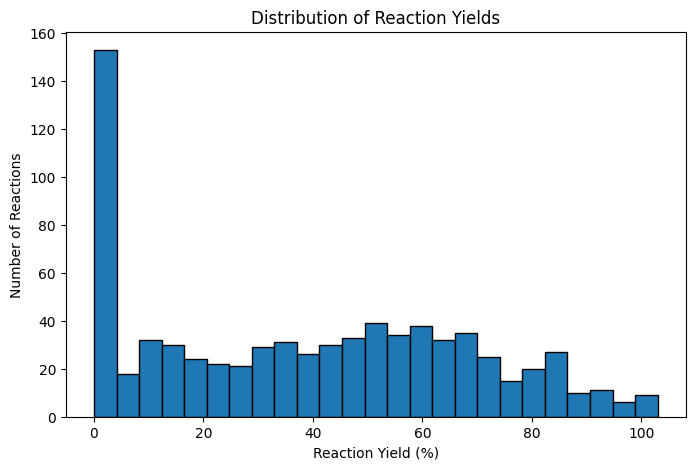

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["yield_percent"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("Reaction Yield (%)")
plt.ylabel("Number of Reactions")
plt.title("Distribution of Reaction Yields")

plt.show()

## 14. Checking missing values

Although all 750 reactions have a reported yield and product SMILES, other
variables may be incomplete.

I will check missing values across the reaction-level dataset before extracting
additional information such as solvents, catalysts and reaction conditions.

In [ ]:
missing = df.isna().sum()

missing_percentage = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_values": missing,
    "missing_percentage": missing_percentage
})

missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

,missing_values,missing_percentage
temperature_c,4,0.53
reaction_id,0,0.00
yield_percent,0,0.00
product_smiles,0,0.00
inputs,0,0.00


## 15. Checking reaction conditions

Temperature is currently one of the experimental conditions extracted from the
ORD records.

I will check its coverage and range before using it in later comparisons with
reaction yield and environmental performance.

In [ ]:
print("Reactions with temperature:", df["temperature_c"].notna().sum())

print("Percentage with temperature:", round(df["temperature_c"].notna().mean() * 100, 2),"%")

print("\nTemperature range:")
print(df["temperature_c"].min(),"to", df["temperature_c"].max(),"°C")

Reactions with temperature: 746
Percentage with temperature: 99.47 %

Temperature range:
20.0 to 200.0 °C


## 16. Extracting chemical inputs

The `inputs` column currently contains nested ORD objects, so it cannot be
directly analyzed like a normal categorical column.

I will flatten these inputs so that each chemical component becomes a separate
row.

For each input, I will keep:

- Reaction ID
- Input category
- Reaction role
- SMILES
- Amount in moles

This will let me determine which materials are being used across the dataset
and identify the roles they play in the reactions.

In [ ]:
input_records = []

for reaction in dataset.reactions:

    for category, reaction_input in reaction.inputs.items():

        for component in reaction_input.components:

            smiles = None

            for identifier in component.identifiers:
                if identifier.type == identifier.SMILES:
                    smiles = identifier.value
                    break

            moles = np.nan

            if component.HasField("amount"):
                if component.amount.HasField("moles"):
                    moles = component.amount.moles.value

            input_records.append({
                "reaction_id": reaction.reaction_id,
                "category": category,
                "reaction_role": component.reaction_role,
                "smiles": smiles,
                "moles": moles
            })

inputs_df = pd.DataFrame(input_records)

print("Total input records:", len(inputs_df))
inputs_df.head()

Total input records: 4489


,reaction_id,category,reaction_role,smiles,moles
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,Base,2,C(=O)([O-])[O-].[Cs+].[Cs+],0.002220
1,ord-56b1f4bfeebc4b8ab990b9804e798aa7,metal and ligand,4,C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=C(C4=CC=CC=C4C=C...,0.000089
2,ord-56b1f4bfeebc4b8ab990b9804e798aa7,metal and ligand,4,C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=...,0.000044
3,ord-56b1f4bfeebc4b8ab990b9804e798aa7,aryl halide,1,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,0.000886
4,ord-56b1f4bfeebc4b8ab990b9804e798aa7,amine,1,CC(C)N1CCNCC1,0.001770


## 17. Input categories

The ORD groups chemicals according to their role in an experiment. I will first
look at the most common categories in our sample.

This will help us understand the types of materials present before deciding
which ones should be treated as reactants, catalysts, solvents or other
process inputs.

In [ ]:
category_counts = inputs_df["category"].value_counts().reset_index()
category_counts.columns = ["category", "count"]
category_counts

,category,count
0,metal and ligand,1498
1,Base,750
2,aryl halide,750
3,amine,750
4,Solvent,741


## 18. Making reaction roles readable

The ORD stores reaction roles internally as numeric enum values. These values
are useful to the database but are not convenient for analysis.

I will convert them into their corresponding ORD names so that the final
dataset is easier to interpret.

In [ ]:
role_enum = dataset.reactions[0].inputs[
    list(dataset.reactions[0].inputs.keys())[0]
].components[0].DESCRIPTOR.fields_by_name["reaction_role"].enum_type

role_names = {
    value.number: value.name
    for value in role_enum.values
}

role_names

{0: 'UNSPECIFIED',
 1: 'REACTANT',
 2: 'REAGENT',
 3: 'SOLVENT',
 4: 'CATALYST',
 5: 'WORKUP',
 6: 'INTERNAL_STANDARD',
 7: 'AUTHENTIC_STANDARD',
 8: 'PRODUCT',
 9: 'BYPRODUCT',
 10: 'SIDE_PRODUCT'}

I will now apply these labels to the input dataset and check how the different
reaction roles are distributed.

In [ ]:
inputs_df["reaction_role_name"] = (
    inputs_df["reaction_role"]
    .map(role_names)
)

role_counts = (
    inputs_df["reaction_role_name"]
    .value_counts()
    .reset_index()
)

role_counts.columns = ["reaction_role", "count"]

role_counts

,reaction_role,count
0,REACTANT,1500
1,CATALYST,1498
2,REAGENT,750
3,SOLVENT,741


## 19. Checking material quantities

Material usage is important for the environmental analysis because quantities
will eventually allow us to estimate material intensity and waste-related
metrics.

I will first check how many input records contain a reported amount in moles.

In [ ]:
total_inputs = len(inputs_df)
inputs_with_moles = inputs_df["moles"].notna().sum()

print("Total input records:", total_inputs)
print("Inputs with reported moles:", inputs_with_moles)
print("Percentage with reported moles:", round(inputs_with_moles / total_inputs * 100, 2),"%")

Total input records: 4489
Inputs with reported moles: 3748
Percentage with reported moles: 83.49 %


## 20. Linking inputs with reaction yield

The next step is to connect the chemical inputs back to the reaction-level
dataset.

This will allow us to investigate questions such as:

- Which input categories are most common in high-yield reactions?
- How much material is used relative to the amount of product obtained?
- Which catalysts or reagents are associated with different reaction
  performance?

For now, I will create a summary of the number of different input components
used in each reaction.

In [ ]:
input_summary = (
    inputs_df
    .groupby("reaction_id")
    .agg(
        num_inputs=("smiles", "count"),
        total_input_moles=("moles", "sum")
    )
    .reset_index()
) #count of no. of input components used in each rxn

df = df.merge(
    input_summary,
    on="reaction_id",
    how="left"
) #added summary to the reaction-level dataset

df.head()

,reaction_id,temperature_c,yield_percent,product_smiles,inputs,num_inputs,total_input_moles
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,110.0,65.389999,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,"[{'category': 'Base', 'reaction_role': 2, 'smi...",5,0.005009
1,ord-1169cbe9fa064a879ac34b2e524a4e69,100.0,57.470001,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.036827
2,ord-13992005c22d4673aa802b5e140076e8,100.0,65.430000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.032521
3,ord-a36b48917c9942d1a34637511773ee1f,100.0,75.070000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.032521
4,ord-5fc624fd97b7430eafbe8dcc049d170b,150.0,46.320000,CC1=NC(=C(C=C1)OC2=CC(=NC=C2)NC3=CC=C(C=C3)S(=...,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.070850


## 21. Calculating molecular weights

The input data currently contains chemical structures as SMILES and quantities
in moles.

To compare material usage across reactions, I need to convert the chemical
structures into molecular weights and then calculate the corresponding mass
used.

I will use RDKit to:

- Parse the SMILES strings
- Calculate molecular weight for each chemical
- Identify invalid or unparseable structures
- Calculate the mass corresponding to the reported number of moles

This will give us a mass-based view of the reaction inputs, which is more useful
for the environmental analysis than comparing moles alone.

In [ ]:
!pip -q install rdkit  #rdkit is used for handling chemical structures and molecular properties

### Adding molecular weights

I will calculate molecular weight from each SMILES string.

Some records may contain salts or multiple molecular fragments, so I will keep
the original SMILES unchanged and let RDKit determine whether the structure can
be parsed successfully.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_molecular_weight(smiles):
    if pd.isna(smiles):
        return np.nan

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return np.nan

    return Descriptors.MolWt(mol)


inputs_df["molecular_weight"] = inputs_df["smiles"].apply(
    get_molecular_weight
)

inputs_df[[
    "category",
    "reaction_role_name",
    "smiles",
    "moles",
    "molecular_weight"
]].head()

[07:04:37] WARNING: not removing hydrogen atom without neighbors


,category,reaction_role_name,smiles,moles,molecular_weight
0,Base,REAGENT,C(=O)([O-])[O-].[Cs+].[Cs+],0.002220,325.818
1,metal and ligand,CATALYST,C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=C(C4=CC=CC=C4C=C...,0.000089,622.688
2,metal and ligand,CATALYST,C1=CC=C(C=C1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C1=CC=...,0.000044,915.734
3,aryl halide,REACTANT,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,0.000886,451.267
4,amine,REACTANT,CC(C)N1CCNCC1,0.001770,128.219


## 22. Checking chemical structure coverage

Before using molecular weights, I will check how many input structures could
actually be parsed by RDKit.

This is important because invalid or unusual SMILES should not silently enter
the mass calculations as zero or another arbitrary value.

In [ ]:
total_structures = inputs_df["smiles"].notna().sum()
valid_structures = inputs_df["molecular_weight"].notna().sum()

print("Input records with SMILES:", total_structures)
print("Successfully parsed structures:", valid_structures)

print("Parsing success rate:", round(valid_structures / total_structures * 100, 2), "%")

Input records with SMILES: 4489
Successfully parsed structures: 4489
Parsing success rate: 100.0 %


## 23. Converting material amounts into mass

For records where both the amount in moles and molecular weight are available,
I can calculate the corresponding mass:

Mass = moles * molecular weight

I will store the result in grams.

This gives us the first mass-based variable that can be used to study material
usage across different reaction processes.

In [ ]:
inputs_df["mass_g"] = (
    inputs_df["moles"] *
    inputs_df["molecular_weight"]
)

inputs_df[[
    "category",
    "reaction_role_name",
    "moles",
    "molecular_weight",
    "mass_g"
]].head()

,category,reaction_role_name,moles,molecular_weight,mass_g
0,Base,REAGENT,0.002220,325.818,0.723316
1,metal and ligand,CATALYST,0.000089,622.688,0.055170
2,metal and ligand,CATALYST,0.000044,915.734,0.040567
3,aryl halide,REACTANT,0.000886,451.267,0.399823
4,amine,REACTANT,0.001770,128.219,0.226948


## 24. Checking mass-data coverage

Not every input has both a reported amount and a valid chemical structure.

I will check how much of the input data can currently be converted into mass.
This will determine how many reactions can support a reliable mass-based
environmental analysis.

In [ ]:
mass_available = inputs_df["mass_g"].notna().sum()

print("Total input records:", len(inputs_df))
print("Records with calculated mass:", mass_available)

print("Mass coverage:", round(mass_available / len(inputs_df) * 100, 2),"%")

Total input records: 4489
Records with calculated mass: 3748
Mass coverage: 83.49 %


## 25. Summarizing material usage by reaction

I will now aggregate the input-level data back to the reaction level.

For each reaction, I will calculate:

- Total input mass
- Number of input components
- Total mass of reactants
- Total mass of reagents
- Total mass of catalysts
- Total mass of solvents

Separating these categories will be important later because solvent usage can
contribute substantially to the material footprint of a process.

In [ ]:
total_mass = (
    inputs_df
    .groupby("reaction_id")["mass_g"]
    .sum(min_count=1)
    .rename("total_input_mass_g")
) #total mass of all inputs for each rxn

role_mass = (
    inputs_df
    .pivot_table(
        index="reaction_id",
        columns="reaction_role_name",
        values="mass_g",
        aggfunc="sum"
    )
) #mass by rxn role

role_mass.columns = [
    f"{col.lower()}_mass_g"
    for col in role_mass.columns
]

mass_summary = pd.concat(
    [total_mass, role_mass],
    axis=1
).reset_index()

mass_summary.head()

,reaction_id,total_input_mass_g,catalyst_mass_g,reactant_mass_g,reagent_mass_g,solvent_mass_g
0,ord-006fb353766e418abd7ffca7f96dda71,1.055274,0.066291,0.337347,0.651636,0.0
1,ord-00b630fb849d46988bc61ed1eeecad73,0.110703,0.007338,0.086354,0.017011,0.0
2,ord-00b95f6f20354bb6923efd18c2b3c116,16.602103,1.054880,10.511321,5.035902,NaN
3,ord-019ad9f92b5c40ecbf5416e8a6461063,1.589725,0.131628,0.698942,0.759156,0.0
4,ord-01bb5c09bf964bc095ad839c85efa1ae,0.345968,0.035448,0.165531,0.144989,0.0


## 26. Combining reaction performance and material usage

The reaction-level dataset already contains yield and temperature.

I will now combine it with the material-mass information so that each reaction
has both its experimental performance and its material usage in the same table.

This will form the basis for the next stage of the environmental analysis.

In [ ]:
df = df.drop(
    columns=[
        col for col in df.columns
        if col.endswith("_mass_g") or col == "total_input_mass_g"
    ],
    errors="ignore"
) #add mass based variables to the main rxn dataset

df = df.merge(
    mass_summary,
    on="reaction_id",
    how="left"
)

df.head()

,reaction_id,temperature_c,yield_percent,product_smiles,inputs,num_inputs,total_input_moles,total_input_mass_g,catalyst_mass_g,reactant_mass_g,reagent_mass_g,solvent_mass_g
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,110.0,65.389999,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,"[{'category': 'Base', 'reaction_role': 2, 'smi...",5,0.005009,1.445823,0.095737,0.626770,0.723316,NaN
1,ord-1169cbe9fa064a879ac34b2e524a4e69,100.0,57.470001,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.036827,10.476247,0.720216,3.565489,6.190542,0.0
2,ord-13992005c22d4673aa802b5e140076e8,100.0,65.430000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.032521,9.253187,0.635173,3.144272,5.473742,0.0
3,ord-a36b48917c9942d1a34637511773ee1f,100.0,75.070000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.032521,9.253187,0.635173,3.144272,5.473742,0.0
4,ord-5fc624fd97b7430eafbe8dcc049d170b,150.0,46.320000,CC1=NC(=C(C=C1)OC2=CC(=NC=C2)NC3=CC=C(C=C3)S(=...,"[{'category': 'Solvent', 'reaction_role': 3, '...",6,0.070850,15.575889,2.034216,12.642416,0.899258,0.0


## 27. Checking product quantities

We have been able to calculate the mass of many reaction inputs from their reported
moles and molecular weights.

To calculate mass-based sustainability metrics, I also need information about the
amount of desired product produced.

I will inspect the product records to see whether ORD reports an actual product
quantity in addition to the percentage yield.

In [ ]:
#Inspecting the fields available for the desired product
for outcome in reaction.outcomes:
    for product in outcome.products:
        if product.is_desired_product:
            print(product.DESCRIPTOR.fields_by_name.keys())
            print()
            print(product)
            break

['identifiers', 'is_desired_product', 'measurements', 'isolated_color', 'texture', 'features', 'reaction_role']

identifiers {
  type: SMILES
  value: "CC(=O)NC1=C(C=CC(=C1)NC2=NC3=C(C=NN3C(=C2)NC4CC4)C#N)N(C)CCCN(C)C"
}
is_desired_product: true
measurements {
  type: YIELD
  percentage {
    value: 29
  }
}
reaction_role: PRODUCT



The product record already contains a reported yield percentage.

I will check all measurement types used for the desired product to determine
whether actual product amounts are available.

In [ ]:
measurement_types = []

for rxn in dataset.reactions:

    for outcome in rxn.outcomes:

        for product in outcome.products:

            if product.is_desired_product:

                for measurement in product.measurements:
                    measurement_types.append(measurement.type)

measurement_types = pd.Series(measurement_types)
print(measurement_types.value_counts())

3    750
Name: count, dtype: int64


## 28. Checking reaction-level information

If the dataset does not contain direct product mass, I will check whether the
reaction records contain additional reaction-level identifiers or information
that can be used to determine the stoichiometry of the reaction.

This will help us decide whether metrics such as atom economy and reaction mass
efficiency can be calculated directly from the ORD data or whether we should
restrict the analysis to metrics that are properly supported by the available
data.

In [ ]:
print(reaction.identifiers)

[type: CUSTOM
details: "reaction index"
value: "997"
, type: REACTION_TYPE
details: "reaction type"
value: "1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination"
]


## 29. Reaction types

The ORD records contain a standardized reaction type for many reactions.

This is useful because environmental performance should not be compared only
across individual reactions. Different reaction classes can have very different
material requirements and operating conditions.

I will extract the reported reaction type and use it to compare groups of
chemically related processes.

In [ ]:
def extract_reaction_type(reaction):

    reaction_type = None

    for identifier in reaction.identifiers:
        if identifier.type == identifier.REACTION_TYPE:
            reaction_type = identifier.value
            break

    return reaction_type


df["reaction_type"] = [
    extract_reaction_type(rxn)
    for rxn in dataset.reactions
]

print("Reactions with reaction type:",
      df["reaction_type"].notna().sum())

df["reaction_type"].head(10)

Reactions with reaction type: 750


,reaction_type
0,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...
1,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...
2,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...
3,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...
4,0.0 [Unassigned] Unrecognized
5,0.0 [Unassigned] Unrecognized
6,0.0 [Unassigned] Unrecognized
7,0.0 [Unassigned] Unrecognized
8,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...
9,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...


## 30. Distribution of reaction types

Before comparing reaction classes, I will check how many distinct reaction
types are present and how frequently they occur.

Very rare reaction types will not provide enough observations for a reliable
group-level comparison, so the frequency distribution will help us decide
which classes can be analyzed statistically.

In [ ]:
reaction_type_counts = (
    df["reaction_type"]
    .value_counts(dropna=False)
    .reset_index()
)

reaction_type_counts.columns = ["reaction_type", "count"]

print("Number of distinct reaction types:",
      df["reaction_type"].nunique())

reaction_type_counts.head(20)

Number of distinct reaction types: 9


,reaction_type,count
0,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,290
1,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,262
2,0.0 [Unassigned] Unrecognized,92
3,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,76
4,1.3.6 [N-arylation with Ar-X] Bromo N-arylation,16
5,1.3.7 [N-arylation with Ar-X] Chloro N-arylation,9
6,1.3.3 [N-arylation with Ar-X] Iodo Buchwald-Ha...,3
7,9.7.39 [Other functional group interconversion...,1
8,1.3.9 [N-arylation with Ar-X] Iodo N-arylation,1


## 31. Summarizing process inputs

The input data contains explicit reaction roles, including reactants, catalysts,
reagents and solvents.

I will create reaction-level indicators for these categories.

For each reaction, I will calculate:

- Number of reactants
- Number of reagents
- Number of catalysts
- Number of solvents
- Total input mass where available
- Catalyst mass where available
- Solvent mass where available

These variables will allow us to compare reaction performance with material
and process requirements.

In [ ]:
component_counts = (
    inputs_df
    .groupby(["reaction_id", "reaction_role_name"])
    .size()
    .unstack(fill_value=0)
) #no. of components by rxn role

# Rename columns
component_counts.columns = [
    f"num_{col.lower()}"
    for col in component_counts.columns
]

component_counts = component_counts.reset_index()

component_counts.head()

,reaction_id,num_catalyst,num_reactant,num_reagent,num_solvent
0,ord-006fb353766e418abd7ffca7f96dda71,2,2,1,1
1,ord-00b630fb849d46988bc61ed1eeecad73,2,2,1,1
2,ord-00b95f6f20354bb6923efd18c2b3c116,2,2,1,0
3,ord-019ad9f92b5c40ecbf5416e8a6461063,2,2,1,1
4,ord-01bb5c09bf964bc095ad839c85efa1ae,2,2,1,1


In [ ]:
df = df.drop(
    columns=[
        col for col in df.columns
        if col.startswith("num_")
    ],
    errors="ignore"
)

df = df.merge(
    component_counts,
    on="reaction_id",
    how="left"
)
#combining
df.head()

,reaction_id,temperature_c,yield_percent,product_smiles,inputs,total_input_moles,total_input_mass_g,catalyst_mass_g,reactant_mass_g,reagent_mass_g,solvent_mass_g,reaction_type,num_catalyst,num_reactant,num_reagent,num_solvent
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,110.0,65.389999,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,"[{'category': 'Base', 'reaction_role': 2, 'smi...",0.005009,1.445823,0.095737,0.626770,0.723316,NaN,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,2,2,1,0
1,ord-1169cbe9fa064a879ac34b2e524a4e69,100.0,57.470001,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.036827,10.476247,0.720216,3.565489,6.190542,0.0,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1
2,ord-13992005c22d4673aa802b5e140076e8,100.0,65.430000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.032521,9.253187,0.635173,3.144272,5.473742,0.0,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1
3,ord-a36b48917c9942d1a34637511773ee1f,100.0,75.070000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.032521,9.253187,0.635173,3.144272,5.473742,0.0,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1
4,ord-5fc624fd97b7430eafbe8dcc049d170b,150.0,46.320000,CC1=NC(=C(C=C1)OC2=CC(=NC=C2)NC3=CC=C(C=C3)S(=...,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.070850,15.575889,2.034216,12.642416,0.899258,0.0,0.0 [Unassigned] Unrecognized,2,2,1,1


## 32. Solvent and catalyst usage

Solvents and catalysts play different roles in a chemical process, so I will
keep them separate.

Solvent mass will be used as a process-input variable, while catalyst usage
will be treated separately because catalysts are generally used in much smaller
quantities and are not stoichiometrically consumed in the same way as reactants.

These variables will later be compared against reaction yield and temperature.

In [ ]:
role_mass_summary = (
    inputs_df
    .pivot_table(
        index="reaction_id",
        columns="reaction_role_name",
        values="mass_g",
        aggfunc="sum"
    )
    .reset_index()
)
#reaction-level mass summaries for important roles
role_mass_summary.head()

reaction_role_name,reaction_id,CATALYST,REACTANT,REAGENT,SOLVENT
0,ord-006fb353766e418abd7ffca7f96dda71,0.066291,0.337347,0.651636,0.0
1,ord-00b630fb849d46988bc61ed1eeecad73,0.007338,0.086354,0.017011,0.0
2,ord-00b95f6f20354bb6923efd18c2b3c116,1.054880,10.511321,5.035902,NaN
3,ord-019ad9f92b5c40ecbf5416e8a6461063,0.131628,0.698942,0.759156,0.0
4,ord-01bb5c09bf964bc095ad839c85efa1ae,0.035448,0.165531,0.144989,0.0


I will rename the relevant columns so they are easier to work with in the
analysis.

In [ ]:
role_mass_summary = role_mass_summary.rename(
    columns={
        "REACTANT": "reactant_mass_g",
        "REAGENT": "reagent_mass_g",
        "CATALYST": "catalyst_mass_g",
        "SOLVENT": "solvent_mass_g",
        "WORKUP": "workup_mass_g"
    }
)

role_mass_summary.head()

reaction_role_name,reaction_id,catalyst_mass_g,reactant_mass_g,reagent_mass_g,solvent_mass_g
0,ord-006fb353766e418abd7ffca7f96dda71,0.066291,0.337347,0.651636,0.0
1,ord-00b630fb849d46988bc61ed1eeecad73,0.007338,0.086354,0.017011,0.0
2,ord-00b95f6f20354bb6923efd18c2b3c116,1.054880,10.511321,5.035902,NaN
3,ord-019ad9f92b5c40ecbf5416e8a6461063,0.131628,0.698942,0.759156,0.0
4,ord-01bb5c09bf964bc095ad839c85efa1ae,0.035448,0.165531,0.144989,0.0


## 33. Final reaction-level dataset

I now have the main variables needed for the process-level analysis.

The dataset combines:

- Reaction performance: yield
- Operating condition: temperature
- Chemical inputs: reactants, reagents, catalysts and solvents
- Material quantities: calculated input masses
- Reaction classification: reaction type

This will be the main analytical table for the rest of the project.

In [ ]:
#merging mass info in main dataset
df = df.drop(
    columns=[
        col for col in [
            "reactant_mass_g",
            "reagent_mass_g",
            "catalyst_mass_g",
            "solvent_mass_g",
            "workup_mass_g"
        ]
        if col in df.columns
    ],
    errors="ignore"
)

df = df.merge(
    role_mass_summary,
    on="reaction_id",
    how="left"
)

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (750, 16)


,reaction_id,temperature_c,yield_percent,product_smiles,inputs,total_input_moles,total_input_mass_g,reaction_type,num_catalyst,num_reactant,num_reagent,num_solvent,catalyst_mass_g,reactant_mass_g,reagent_mass_g,solvent_mass_g
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,110.0,65.389999,CCOC1=C(C=C2C(=C1)N=CC(=C2NC3=C(C=C(C=C3)F)F)C...,"[{'category': 'Base', 'reaction_role': 2, 'smi...",0.005009,1.445823,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,2,2,1,0,0.095737,0.626770,0.723316,NaN
1,ord-1169cbe9fa064a879ac34b2e524a4e69,100.0,57.470001,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.036827,10.476247,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1,0.720216,3.565489,6.190542,0.0
2,ord-13992005c22d4673aa802b5e140076e8,100.0,65.430000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.032521,9.253187,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1,0.635173,3.144272,5.473742,0.0
3,ord-a36b48917c9942d1a34637511773ee1f,100.0,75.070000,CN1C=NC2=C1C=C(C(=C2F)NC3=CC=CC=C3)C(=O)OC,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.032521,9.253187,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,2,2,1,1,0.635173,3.144272,5.473742,0.0
4,ord-5fc624fd97b7430eafbe8dcc049d170b,150.0,46.320000,CC1=NC(=C(C=C1)OC2=CC(=NC=C2)NC3=CC=C(C=C3)S(=...,"[{'category': 'Solvent', 'reaction_role': 3, '...",0.070850,15.575889,0.0 [Unassigned] Unrecognized,2,2,1,1,2.034216,12.642416,0.899258,0.0


## 34. Process-level summary

Before comparing reaction types, I will look at the distributions of the main
process variables.

This will show how different the reactions are in terms of yield, temperature,
material usage and solvent/catalyst requirements.

In [ ]:
analysis_columns = [
    "yield_percent",
    "temperature_c",
    "reactant_mass_g",
    "reagent_mass_g",
    "catalyst_mass_g",
    "solvent_mass_g"
]

df[analysis_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
yield_percent,750.0,38.811253,29.397853,0.000000,10.487500,39.930000,61.977501,102.970001
temperature_c,746.0,107.916890,22.826890,20.000000,100.000000,100.000000,120.000000,200.000000
reactant_mass_g,750.0,3.086843,8.066180,0.008171,0.201456,0.441333,1.993608,122.905147
reagent_mass_g,750.0,1.813186,6.009693,0.000000,0.086543,0.330052,1.036589,107.194121
catalyst_mass_g,750.0,0.512145,1.354480,0.001050,0.035448,0.090880,0.354868,18.706529
solvent_mass_g,741.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 36. Correcting missing material quantities

Some ORD input records do not contain a reported amount in moles.

When aggregating these records, a normal sum can incorrectly turn a group
containing only missing values into zero. That would make missing material
information look like zero material usage.

I will therefore require at least one valid mass value when calculating
reaction-level mass totals.

This distinction is important for the later analysis because:

- `0` means a reported/calculable mass is zero
- `NaN` means the available ORD information is insufficient to calculate it

In [ ]:
#recalculating mass summaries while preserving missing values
total_mass = (
    inputs_df
    .groupby("reaction_id")["mass_g"]
    .sum(min_count=1)
    .rename("total_input_mass_g")
)

role_mass_summary = (
    inputs_df
    .pivot_table(
        index="reaction_id",
        columns="reaction_role_name",
        values="mass_g",
        aggfunc=lambda x: x.sum(min_count=1)
    )
    .reset_index()
)

role_mass_summary = role_mass_summary.rename(
    columns={
        "REACTANT": "reactant_mass_g",
        "REAGENT": "reagent_mass_g",
        "CATALYST": "catalyst_mass_g",
        "SOLVENT": "solvent_mass_g",
        "WORKUP": "workup_mass_g"
    }
)

role_mass_summary.head()

reaction_role_name,reaction_id,catalyst_mass_g,reactant_mass_g,reagent_mass_g
0,ord-006fb353766e418abd7ffca7f96dda71,0.066291,0.337347,0.651636
1,ord-00b630fb849d46988bc61ed1eeecad73,0.007338,0.086354,0.017011
2,ord-00b95f6f20354bb6923efd18c2b3c116,1.054880,10.511321,5.035902
3,ord-019ad9f92b5c40ecbf5416e8a6461063,0.131628,0.698942,0.759156
4,ord-01bb5c09bf964bc095ad839c85efa1ae,0.035448,0.165531,0.144989


I will check how many reactions have enough information to calculate the mass
of each input category.

This will tell us which material variables are suitable for quantitative
analysis and which ones should be treated as missing rather than zero.

In [ ]:
mass_columns = [
    "reactant_mass_g",
    "reagent_mass_g",
    "catalyst_mass_g",
    "solvent_mass_g",
    "workup_mass_g"
]

# Add missing role columns as NaN
for col in mass_columns:
    if col not in role_mass_summary.columns:
        role_mass_summary[col] = np.nan

mass_coverage = pd.DataFrame({
    "available_values": role_mass_summary[mass_columns].notna().sum(),
    "coverage_percent": (
        role_mass_summary[mass_columns].notna().mean() * 100
    ).round(2)
})

mass_coverage

,available_values,coverage_percent
reaction_role_name,,
reactant_mass_g,750,100.0
reagent_mass_g,750,100.0
catalyst_mass_g,750,100.0
solvent_mass_g,0,0.0
workup_mass_g,0,0.0


## 38. Investigating solvent quantities

Solvents are potentially one of the most important contributors to material
usage in a chemical process.

The initial aggregation showed no calculated solvent mass, so I will inspect
how solvent amounts are represented in the ORD records.

The ORD may report solvent quantities using units other than moles, such as
volume. If that information is available, we can handle it separately rather
than incorrectly treating the solvent mass as zero.

In [ ]:
solvent_found = False
#finding the first solvent component in the dataset
for rxn in dataset.reactions:

    for category, reaction_input in rxn.inputs.items():

        if category.upper() == "SOLVENT":

            for component in reaction_input.components:

                print(component)
                solvent_found = True
                break

        if solvent_found:
            break

    if solvent_found:
        break

identifiers {
  type: SMILES
  value: "COC1=CC=CC=C1"
}
amount {
  volume {
    value: 0.0332
    units: LITER
  }
}
reaction_role: SOLVENT
is_limiting: false



## 39. Reaction-type coverage

Most reactions in this file belong to a small number of related N-arylation
classes, while 92 reactions are marked as unassigned.

I will quantify the classified portion of the dataset before using reaction
type as a comparison variable.

In [ ]:
classified = df["reaction_type"].notna()

print("Classified reactions:", classified.sum())
print("Unclassified reactions:", (~classified).sum())

print("Classification coverage:", round(classified.mean() * 100, 2),"%")

Classified reactions: 750
Unclassified reactions: 0
Classification coverage: 100.0 %


## 40. Extracting solvent volume

The ORD records report solvent quantities using volume rather than moles.

Since solvent density is not provided directly in the reaction record, I will
keep solvent usage as volume rather than converting it to mass using external
assumptions.

This gives us a directly reported process variable that can be compared across
reactions.

I will extract:

- Solvent identity
- Solvent volume in liters
- Number of solvent components

In [ ]:
def extract_solvents(reaction):

    solvents = []

    for category, reaction_input in reaction.inputs.items():

        if category.upper() != "SOLVENT":
            continue

        for component in reaction_input.components:

            smiles = None

            for identifier in component.identifiers:
                if identifier.type == identifier.SMILES:
                    smiles = identifier.value
                    break

            volume_l = np.nan

            if component.HasField("amount"):
                if component.amount.HasField("volume"):
                    volume = component.amount.volume

                    if volume.units == volume.LITER:
                        volume_l = volume.value

            solvents.append({
                "reaction_id": reaction.reaction_id,
                "solvent_smiles": smiles,
                "volume_l": volume_l
            })

    return solvents

I will test the solvent extraction on the sample reaction to make sure the
reported volume is being captured correctly.

In [ ]:
sample_solvents = extract_solvents(reaction)
pd.DataFrame(sample_solvents)

,reaction_id,solvent_smiles,volume_l
0,ord-f3666d844cbc446dba498aa63de90f9a,CC(=O)N(C)C,0.0005


## 42. Building the solvent-level dataset

I will now apply the solvent extraction to all 750 reactions.

This creates a separate solvent-level table because a reaction can contain
multiple solvent components.

In [ ]:
solvent_records = []

for rxn in dataset.reactions:
    solvent_records.extend(extract_solvents(rxn))

solvents_df = pd.DataFrame(solvent_records)

print("Total solvent records:", len(solvents_df))

solvents_df.head()

Total solvent records: 741


,reaction_id,solvent_smiles,volume_l
0,ord-1169cbe9fa064a879ac34b2e524a4e69,COC1=CC=CC=C1,0.0332
1,ord-13992005c22d4673aa802b5e140076e8,COC1=CC=CC=C1,0.0149
2,ord-a36b48917c9942d1a34637511773ee1f,COC1=CC=CC=C1,0.0298
3,ord-5fc624fd97b7430eafbe8dcc049d170b,CC(=O)N(C)C,0.1300
4,ord-c34e3f2a76e4462999414a169b276944,CC(=O)N(C)C,0.2000


## 43. Solvent usage coverage

I will check how many reactions have a reported solvent volume.

This tells us how much of the dataset can be used for solvent-related process
analysis.

In [ ]:
solvent_reaction_summary = (
    solvents_df
    .groupby("reaction_id")
    .agg(
        num_solvents=("solvent_smiles", "count"),
        total_solvent_volume_l=("volume_l", "sum")
    )
    .reset_index()
)

print(
    "Reactions with solvent information:",
    solvent_reaction_summary["reaction_id"].nunique()
)

print(
    "Percentage:",
    round(
        solvent_reaction_summary["reaction_id"].nunique()
        / len(df) * 100,
        2
    ),
    "%"
)

Reactions with solvent information: 741
Percentage: 98.8 %


## 44. Adding solvent usage to the reaction dataset

I will now add the solvent volume to the main reaction-level dataset.

Solvent volume will remain separate from the mass-based input variables because
the ORD reports it directly as volume and we do not have reliable density
information for every solvent.

In [ ]:
df = df.drop(
    columns=[
        "num_solvents",
        "total_solvent_volume_l"
    ],
    errors="ignore"
)

df = df.merge(
    solvent_reaction_summary,
    on="reaction_id",
    how="left"
)

df[[
    "reaction_id",
    "yield_percent",
    "temperature_c",
    "num_solvents",
    "total_solvent_volume_l"
]].head()

,reaction_id,yield_percent,temperature_c,num_solvents,total_solvent_volume_l
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,65.389999,110.0,NaN,NaN
1,ord-1169cbe9fa064a879ac34b2e524a4e69,57.470001,100.0,1.0,0.0332
2,ord-13992005c22d4673aa802b5e140076e8,65.430000,100.0,1.0,0.0149
3,ord-a36b48917c9942d1a34637511773ee1f,75.070000,100.0,1.0,0.0298
4,ord-5fc624fd97b7430eafbe8dcc049d170b,46.320000,150.0,1.0,0.1300


## 45. Solvent usage distribution

I will look at the distribution of reported solvent volumes.

A highly skewed distribution would indicate that a small number of reactions
use substantially more solvent than the rest, which is important when comparing
process efficiency.

In [ ]:
print(df["total_solvent_volume_l"].describe())

count    741.000000
mean       0.034561
std        0.121078
min        0.000000
25%        0.002250
50%        0.005000
75%        0.020000
max        2.250000
Name: total_solvent_volume_l, dtype: float64


## 46. Yield versus solvent usage

I want to determine whether using more solvent is associated with better reaction
performance.

A higher solvent volume does not necessarily mean a worse process, since larger
amounts may sometimes be required by the reaction scale. Therefore, I will look
for an association rather than assuming that more solvent directly causes lower
efficiency.

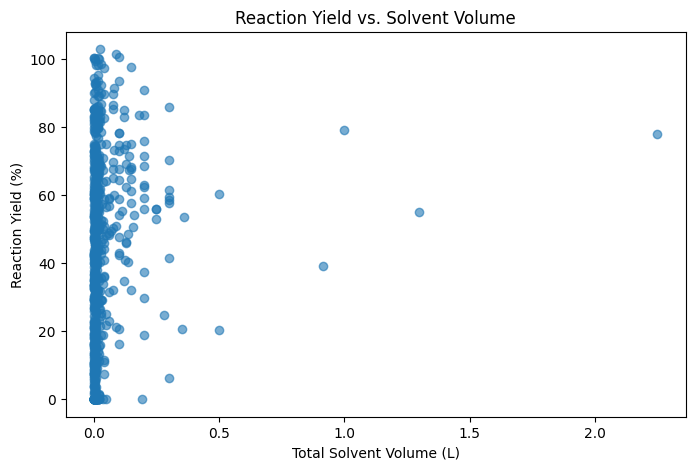

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["total_solvent_volume_l"],
    df["yield_percent"],
    alpha=0.6
)

plt.xlabel("Total Solvent Volume (L)")
plt.ylabel("Reaction Yield (%)")
plt.title("Reaction Yield vs. Solvent Volume")

plt.show()

The scatter plot gives a visual indication of the relationship, but I also want
a numerical measure.

I will calculate the Pearson and Spearman correlations.

Pearson correlation measures a linear relationship, while Spearman correlation
is based on ranks and is less sensitive to extreme values.

In [ ]:
correlation_data = df[
    ["yield_percent", "total_solvent_volume_l"]].dropna()

pearson_corr = correlation_data.corr(method="pearson").loc[
    "yield_percent",
    "total_solvent_volume_l"
]

spearman_corr = correlation_data.corr(method="spearman").loc[
    "yield_percent",
    "total_solvent_volume_l"
]

print("Pearson correlation:", round(pearson_corr, 3))
print("Spearman correlation:", round(spearman_corr, 3))

Pearson correlation: 0.16
Spearman correlation: 0.356


## 47. Yield versus material usage

Next, I will examine whether reactions using larger quantities of reactants
and reagents tend to achieve higher yields.

Because the input masses are measured at the reaction level, these variables
provide a first indication of the material requirements associated with
different reaction outcomes.

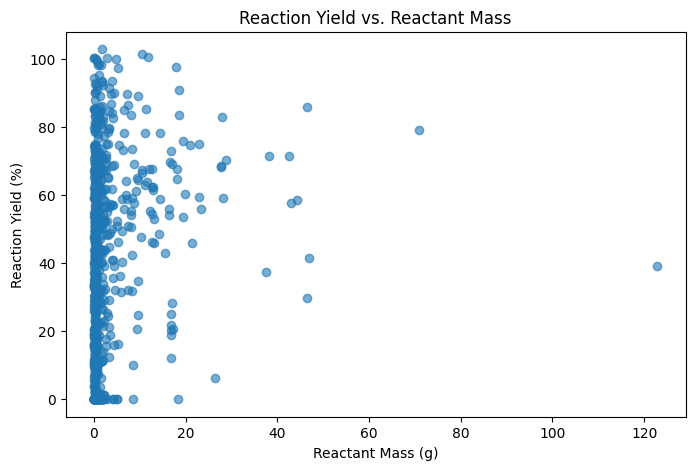

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["reactant_mass_g"],
    df["yield_percent"],
    alpha=0.6
)

plt.xlabel("Reactant Mass (g)")
plt.ylabel("Reaction Yield (%)")
plt.title("Reaction Yield vs. Reactant Mass")

plt.show()

## 48. Catalyst usage and reaction yield

Catalysts are particularly interesting in this dataset because nearly every
reaction contains a catalyst.

I will check whether catalyst mass shows any relationship with reaction yield.

This should be interpreted carefully: catalyst mass alone does not represent
catalytic efficiency because the molecular weight and catalyst loading relative
to the reactant amount also matter.

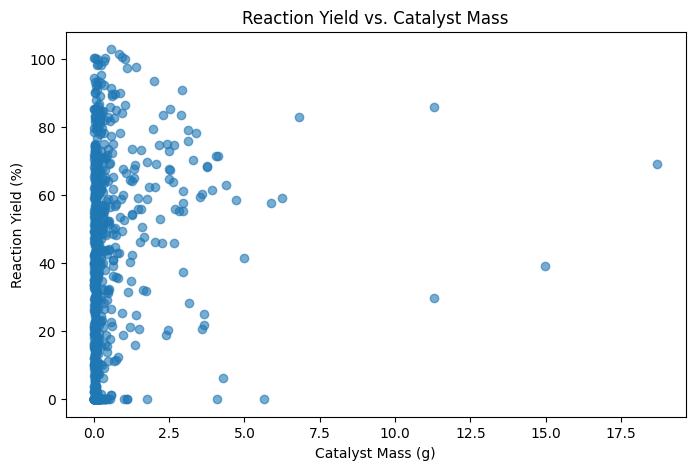

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["catalyst_mass_g"],
    df["yield_percent"],
    alpha=0.6
)

plt.xlabel("Catalyst Mass (g)")
plt.ylabel("Reaction Yield (%)")
plt.title("Reaction Yield vs. Catalyst Mass")

plt.show()

## 49. Reaction temperature and yield

Temperature is an operating-condition variable that may influence both reaction
performance and energy requirements.

I will examine whether higher reaction temperatures are associated with higher
reported yields in this dataset.

In [ ]:
temperature_data = df[
    ["temperature_c", "yield_percent"]
].dropna()

temperature_corr = temperature_data.corr(
    method="spearman"
).loc[
    "temperature_c",
    "yield_percent"
]

print(
    "Spearman correlation between temperature and yield:",
    round(temperature_corr, 3)
)

Spearman correlation between temperature and yield: -0.099


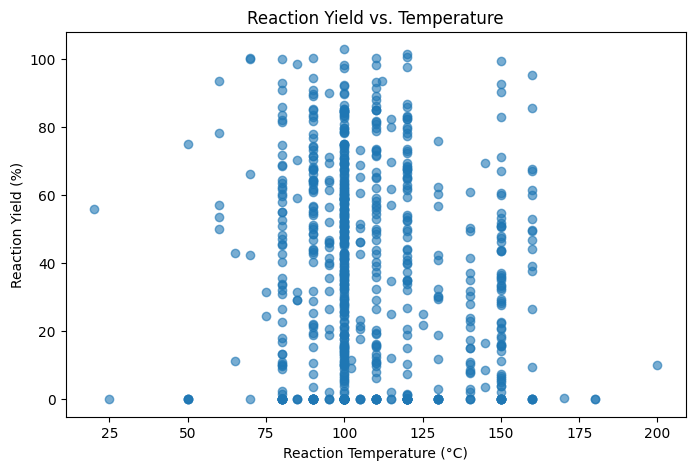

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature_c"],
    df["yield_percent"],
    alpha=0.6
)

plt.xlabel("Reaction Temperature (°C)")
plt.ylabel("Reaction Yield (%)")
plt.title("Reaction Yield vs. Temperature")

plt.show()

## 50. Comparing high- and low-yield processes

Instead of looking only at correlations, I will divide the reactions into
yield groups.

The top 25% of reactions will be treated as the high-yield group, while the
bottom 25% will represent the low-yield group.

I will compare their typical temperature, material usage and solvent volume.

This is not intended to establish causation. It is a descriptive comparison
of the process characteristics associated with different levels of reaction
performance.

In [ ]:
yield_q25 = df["yield_percent"].quantile(0.25)
yield_q75 = df["yield_percent"].quantile(0.75)

df["yield_group"] = np.select(
    [
        df["yield_percent"] <= yield_q25,
        df["yield_percent"] >= yield_q75
    ],
    [
        "Low yield",
        "High yield"
    ],
    default="Middle yield"
)

print("Low-yield threshold:", round(yield_q25, 2), "%")
print("High-yield threshold:", round(yield_q75, 2), "%")

df["yield_group"].value_counts()

Low-yield threshold: 10.49 %
High-yield threshold: 61.98 %


,count
yield_group,
Middle yield,374
High yield,188
Low yield,188


I will now compare the process variables across the three yield groups.

This should reveal whether the highest-yield reactions achieve their performance
with substantially different material requirements or operating conditions.

In [ ]:
group_summary = (
    df
    .groupby("yield_group")
    [[
            "yield_percent",
            "temperature_c",
            "reactant_mass_g",
            "reagent_mass_g",
            "catalyst_mass_g",
            "total_solvent_volume_l"
    ]]
    .median().reindex(["Low yield", "Middle yield", "High yield"])
)

group_summary

,yield_percent,temperature_c,reactant_mass_g,reagent_mass_g,catalyst_mass_g,total_solvent_volume_l
yield_group,,,,,,
Low yield,0.000000,100.0,0.253003,0.185323,0.049207,0.004
Middle yield,39.930000,100.0,0.425074,0.386094,0.087353,0.005
High yield,74.900002,100.0,1.334888,0.651636,0.219468,0.015


## 51. Comparing reaction types

The dataset contains several related N-arylation reaction classes.

I will focus on reaction types with enough observations to make a meaningful
descriptive comparison and exclude the very small groups.

For each major reaction type, I will compare:

- Number of reactions
- Median yield
- Median temperature
- Median solvent volume
- Median reactant mass

In [ ]:
reaction_type_summary = (
    df.groupby("reaction_type").agg(
        reactions=("reaction_id", "count"),
        median_yield=("yield_percent", "median"),
        median_temperature=("temperature_c", "median"),
        median_solvent_volume=("total_solvent_volume_l", "median"),
        median_reactant_mass=("reactant_mass_g", "median")
    ).sort_values("reactions",ascending=False)
)

reaction_type_summary

,reactions,median_yield,median_temperature,median_solvent_volume,median_reactant_mass
reaction_type,,,,,
1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination,290,32.395000,100.0,0.004,0.271635
1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination,262,42.799999,100.0,0.010,0.957213
0.0 [Unassigned] Unrecognized,92,49.055000,100.0,0.009,0.765633
1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,76,48.469999,92.5,0.015,1.525211
1.3.6 [N-arylation with Ar-X] Bromo N-arylation,16,20.040000,112.5,0.008,0.892764
1.3.7 [N-arylation with Ar-X] Chloro N-arylation,9,53.599998,120.0,0.007,0.450258
1.3.3 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,3,56.049999,80.0,0.004,0.412884
1.3.9 [N-arylation with Ar-X] Iodo N-arylation,1,40.509998,110.0,0.137,6.076994
9.7.39 [Other functional group interconversion] Chloro to amino,1,25.340000,90.0,0.028,2.905298


The reaction-type comparison will help us separate differences caused by
individual process choices from differences associated with the underlying
reaction class.

For the remainder of the analysis, I will primarily focus on reaction classes
with a reasonable number of observations rather than drawing conclusions from
groups containing only a few reactions.

## 53. Normalizing material usage by reaction scale

The previous analysis showed that high-yield reactions tend to use larger
absolute quantities of reactants, reagents and catalysts.

Absolute mass alone is therefore not sufficient for comparing process
efficiency because reactions may have been performed at different scales.

To make the comparison more meaningful, I will normalize material usage by
the amount of a key reactant used in the reaction.

For this dataset, the aryl halide is a particularly useful reference because
the dominant reaction classes are N-arylation reactions involving an aryl
halide.

The resulting variables will describe how much material and solvent were used
relative to the reaction scale rather than simply measuring total grams.

In [ ]:
def extract_role_moles(reaction, target_role):

    total_moles = 0.0
    found = False

    for category, reaction_input in reaction.inputs.items():

        if category.upper() != target_role:
            continue

        for component in reaction_input.components:

            if not component.HasField("amount"):
                continue

            if component.amount.HasField("moles"):

                moles = component.amount.moles

                if moles.units == moles.MOLE:
                    total_moles += moles.value
                    found = True

    return total_moles if found else np.nan

The reaction records contain input categories such as `aryl halide`, `amine`,
`Base`, and `metal and ligand`.

I will extract the total reported moles of the aryl halide for each reaction.
This will give us a common scale variable for the dominant reaction family.

In [ ]:
aryl_halide_moles = []

for rxn in dataset.reactions:

    value = extract_role_moles(
        rxn,
        "ARYL HALIDE"
    )

    aryl_halide_moles.append(value)

df["aryl_halide_moles"] = aryl_halide_moles

print(
    "Reactions with aryl halide moles:",
    df["aryl_halide_moles"].notna().sum()
)

df["aryl_halide_moles"].describe()

Reactions with aryl halide moles: 750


,aryl_halide_moles
count,750.000000
mean,0.007120
std,0.018081
min,0.000018
25%,0.000483
50%,0.001010
75%,0.004987
max,0.274000


## 54. Scale-normalized process variables

I will now express the main material variables relative to the amount of aryl
halide used.

The normalized variables are:

- Reactant mass per mole of aryl halide
- Reagent mass per mole of aryl halide
- Catalyst mass per mole of aryl halide
- Solvent volume per mole of aryl halide

This allows reactions performed at different scales to be compared more
fairly.

In [ ]:
scale = df["aryl_halide_moles"]

df["reactant_mass_per_mol_aryl"] = (
    df["reactant_mass_g"] / scale
)

df["reagent_mass_per_mol_aryl"] = (
    df["reagent_mass_g"] / scale
)

df["catalyst_mass_per_mol_aryl"] = (
    df["catalyst_mass_g"] / scale
)

df["solvent_l_per_mol_aryl"] = (
    df["total_solvent_volume_l"] / scale
)

normalized_columns = [
    "reactant_mass_per_mol_aryl",
    "reagent_mass_per_mol_aryl",
    "catalyst_mass_per_mol_aryl",
    "solvent_l_per_mol_aryl"
]

df[normalized_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
reactant_mass_per_mol_aryl,750.0,451.748404,196.777288,214.440600,355.307722,441.925000,505.976648,4524.403678
reagent_mass_per_mol_aryl,750.0,344.510243,333.006215,0.000000,112.214352,224.426000,488.727000,3258.180076
catalyst_mass_per_mol_aryl,750.0,94.689072,195.654217,0.308592,55.414852,73.595003,103.638390,5135.159222
solvent_l_per_mol_aryl,741.0,7.967023,38.340621,0.000000,3.303965,4.694836,7.898894,1008.968617


## 55. Normalized material usage versus yield

Previously, high-yield reactions appeared to use more material because they were
often performed at larger scale.

I will now check whether the relationship remains after normalizing the
quantities by aryl-halide scale.

If the relationships become weaker, this would suggest that much of the
previous association was driven by reaction scale rather than process
efficiency itself.

In [ ]:
for column in normalized_columns:

    data = df[
        ["yield_percent", column]
    ].dropna()

    correlation = data.corr(
        method="spearman"
    ).loc[
        "yield_percent",
        column
    ]

    print(
        column,
        "Spearman correlation:",
        round(correlation, 3)
    )

reactant_mass_per_mol_aryl Spearman correlation: 0.11
reagent_mass_per_mol_aryl Spearman correlation: -0.026
catalyst_mass_per_mol_aryl Spearman correlation: 0.009
solvent_l_per_mol_aryl Spearman correlation: -0.006


## 57. Investigating extreme normalized values

The scale-normalized variables contain several extreme values.

These can occur when the amount of aryl halide is very small. Dividing by a
very small reaction scale can produce a very large normalized value even when
the absolute material quantity is reasonable.

I will identify the reactions responsible for the largest normalized values
before deciding how to handle them.

In [ ]:
extreme_columns = [
    "reactant_mass_per_mol_aryl",
    "reagent_mass_per_mol_aryl",
    "catalyst_mass_per_mol_aryl",
    "solvent_l_per_mol_aryl"
]

for column in extreme_columns:

    print("\n", "=" * 70)
    print(column)

    display(
        df[
            [
                "reaction_id",
                "reaction_type",
                "yield_percent",
                "aryl_halide_moles",
                column
            ]
        ]
        .sort_values(column, ascending=False)
        .head(5)
    )


reactant_mass_per_mol_aryl


,reaction_id,reaction_type,yield_percent,aryl_halide_moles,reactant_mass_per_mol_aryl
117,ord-9c57f3e17c814398b6e1a1b710de4610,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,0.000000,0.000925,4524.403678
187,ord-259872fd14244b3c874c12524fba3d75,0.0 [Unassigned] Unrecognized,34.930000,0.000369,1087.680962
634,ord-839e83634a9943b98e2511e3c8112ffb,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,57.110001,0.003910,1013.755741
745,ord-2d4ae739f81c45c1ab0faf1d764941ef,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,42.820000,0.000683,956.436221
719,ord-7a7d88bb15974f808c2ac9e73fb46a04,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,39.250000,0.002310,917.070559



reagent_mass_per_mol_aryl


,reaction_id,reaction_type,yield_percent,aryl_halide_moles,reagent_mass_per_mol_aryl
50,ord-d5a89652aac64eea875d9bd85a60b6b2,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,0.000000,0.000248,3258.180076
586,ord-81f0402c864a4618afac454715899838,1.3.6 [N-arylation with Ar-X] Bromo N-arylation,15.700000,0.001190,2464.169681
598,ord-e6335b06fa23489ab5143a6fe79c709a,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,37.230000,0.000710,2280.726080
188,ord-e345842737b540bdabd050997047f016,0.0 [Unassigned] Unrecognized,66.940002,0.001730,1307.038711
187,ord-259872fd14244b3c874c12524fba3d75,0.0 [Unassigned] Unrecognized,34.930000,0.000369,1306.803929



catalyst_mass_per_mol_aryl


,reaction_id,reaction_type,yield_percent,aryl_halide_moles,catalyst_mass_per_mol_aryl
58,ord-bd19c64fd71c4dc0a1f39c0c85d4d230,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,0.000000,0.001100,5135.159222
479,ord-74d98b785957480d946a0d3ab89bccf5,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,69.110001,0.026600,703.253000
656,ord-135c33d2da2b4d7f90276e4b49e654c9,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,34.730000,0.000423,643.262139
360,ord-4973899cb35d49cd8a53a56048cd33f7,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,0.000000,0.001010,532.378457
419,ord-d45c4d4f76fd453681edb48cc851d97a,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,4.000000,0.000125,506.172983



solvent_l_per_mol_aryl


,reaction_id,reaction_type,yield_percent,aryl_halide_moles,solvent_l_per_mol_aryl
743,ord-b3fb1d017e3744dea3ab3e0ecb0c58d8,0.0 [Unassigned] Unrecognized,78.080002,0.002230,1008.968617
588,ord-2d0a333d9cfc43c6a6709471b22f0443,0.0 [Unassigned] Unrecognized,55.029999,0.005070,256.410249
656,ord-135c33d2da2b4d7f90276e4b49e654c9,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,34.730000,0.000423,47.281324
655,ord-6baac44dbbb745bfaa3ee3e69cefbcee,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,26.540001,0.000529,47.258979
596,ord-18a5ade19723420ab980b1bccfb56a9b,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,0.000000,0.000108,46.296295


## 58. Handling extreme observations

The purpose of the analysis is to compare typical process behavior rather than
allow a small number of extreme observations to dominate the results.

I will therefore use percentile-based limits for the normalized variables.

Values above the 99th percentile will be excluded from the efficiency comparison.
The original data will remain unchanged; this filtering will only be applied to
the analytical subset.

This approach avoids arbitrarily choosing a numerical cutoff for each chemical
variable.

In [ ]:
analysis_df = df.copy()

for column in extreme_columns:

    upper_limit = analysis_df[column].quantile(0.99)

    analysis_df.loc[
        analysis_df[column] > upper_limit,
        column
    ] = np.nan

print("Original reactions:", len(df))
print("Analysis reactions:", len(analysis_df))

Original reactions: 750
Analysis reactions: 750


## 59. Normalized process variables after outlier handling

I will check the distributions again after limiting the influence of extreme
observations.

The goal is not to remove chemically unusual reactions from the dataset, but
to prevent extreme ratios caused by very small denominators from dominating
comparisons between reaction processes.

In [ ]:
analysis_df[extreme_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
reactant_mass_per_mol_aryl,742.0,441.563889,119.426898,214.440600,355.307722,441.067808,503.460979,866.264199
reagent_mass_per_mol_aryl,744.0,331.263841,292.161268,0.000000,112.213000,209.682602,488.726988,1303.272000
catalyst_mass_per_mol_aryl,742.0,83.841710,49.445454,0.308592,55.413748,73.577521,102.246317,328.289864
solvent_l_per_mol_aryl,734.0,6.036557,4.598603,0.000000,3.292188,4.687500,7.847035,27.472528


## 60. Rechecking normalized relationships

I will recalculate the yield correlations after handling extreme normalized
values.

This provides a more stable estimate of the relationship between reaction
performance and normalized material usage.

In [ ]:
for column in extreme_columns:
    data = analysis_df[["yield_percent", column]].dropna()
    correlation = data.corr(method="spearman").loc["yield_percent",column]
    print(column,"Spearman correlation:",round(correlation, 3))

reactant_mass_per_mol_aryl Spearman correlation: 0.12
reagent_mass_per_mol_aryl Spearman correlation: -0.021
catalyst_mass_per_mol_aryl Spearman correlation: 0.014
solvent_l_per_mol_aryl Spearman correlation: 0.001


## 61. Defining process-efficiency dimensions

Rather than assigning arbitrary weights to different environmental variables,
I will use a multi-objective comparison.

A process is preferable when it combines:

- High reaction yield
- Low normalized reactant usage
- Low normalized reagent usage
- Low normalized catalyst usage
- Low normalized solvent usage
- Lower reaction temperature

These objectives can conflict with one another. For example, a reaction may
achieve a high yield but require substantially more solvent.

I will therefore identify Pareto-efficient reactions rather than forcing all
objectives into a single weighted score.

In [ ]:
efficiency_columns = [
    "yield_percent",
    "reactant_mass_per_mol_aryl",
    "reagent_mass_per_mol_aryl",
    "catalyst_mass_per_mol_aryl",
    "solvent_l_per_mol_aryl",
    "temperature_c"
]

efficiency_df = analysis_df[["reaction_id", "reaction_type"] + efficiency_columns].dropna()
print("Reactions available for multi-objective analysis:",len(efficiency_df))
efficiency_df.head()

Reactions available for multi-objective analysis: 716


,reaction_id,reaction_type,yield_percent,reactant_mass_per_mol_aryl,reagent_mass_per_mol_aryl,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl,temperature_c
1,ord-1169cbe9fa064a879ac34b2e524a4e69,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,57.470001,390.097237,677.302185,78.798300,3.632385,100.0
2,ord-13992005c22d4673aa802b5e140076e8,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,65.430000,390.108145,679.124351,78.805604,1.848635,100.0
3,ord-a36b48917c9942d1a34637511773ee1f,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,75.070000,390.108145,679.124351,78.805604,3.697270,100.0
4,ord-5fc624fd97b7430eafbe8dcc049d170b,0.0 [Unassigned] Unrecognized,46.320000,458.058539,32.581801,73.703468,4.710145,150.0
5,ord-c34e3f2a76e4462999414a169b276944,0.0 [Unassigned] Unrecognized,76.029999,458.638554,32.581800,73.709246,4.694836,130.0


## 62. Identifying Pareto-efficient processes

For this analysis, yield is maximized while material usage, solvent usage,
catalyst usage and temperature are minimized.

A reaction is Pareto-efficient when no other reaction performs at least as well
on every selected metric while performing strictly better on at least one.

These reactions represent different trade-offs rather than a single universally
"best" process.

In [ ]:
def is_dominated(row, data):
    #Higher is better for yield
    #Lower is better for all other variables

    better_or_equal = (
        (data["yield_percent"] >= row["yield_percent"]) &
        (data["reactant_mass_per_mol_aryl"] <= row["reactant_mass_per_mol_aryl"]) &
        (data["reagent_mass_per_mol_aryl"] <= row["reagent_mass_per_mol_aryl"]) &
        (data["catalyst_mass_per_mol_aryl"] <= row["catalyst_mass_per_mol_aryl"]) &
        (data["solvent_l_per_mol_aryl"] <= row["solvent_l_per_mol_aryl"]) &
        (data["temperature_c"] <= row["temperature_c"])
    )

    strictly_better = (
        (data["yield_percent"] > row["yield_percent"]) |
        (data["reactant_mass_per_mol_aryl"] < row["reactant_mass_per_mol_aryl"]) |
        (data["reagent_mass_per_mol_aryl"] < row["reagent_mass_per_mol_aryl"]) |
        (data["catalyst_mass_per_mol_aryl"] < row["catalyst_mass_per_mol_aryl"]) |
        (data["solvent_l_per_mol_aryl"] < row["solvent_l_per_mol_aryl"]) |
        (data["temperature_c"] < row["temperature_c"])
    )

    return (better_or_equal & strictly_better).any()


efficiency_df["dominated"] = efficiency_df.apply(
    lambda row: is_dominated(row, efficiency_df),
    axis=1
)

efficiency_df["pareto_efficient"] = ~efficiency_df["dominated"]

print("Pareto-efficient reactions:", efficiency_df["pareto_efficient"].sum())

print("Percentage:",round(efficiency_df["pareto_efficient"].mean() * 100, 2),"%")

Pareto-efficient reactions: 116
Percentage: 16.2 %


## 63. Inspecting Pareto-efficient reactions

The Pareto-efficient set represents reactions for which improving one objective
would require accepting a trade-off in at least one other objective.

I will inspect these reactions to see which reaction classes and process
conditions appear most frequently among the efficient set.

In [ ]:
pareto_reactions = (efficiency_df[efficiency_df["pareto_efficient"]]
    .sort_values(
      "yield_percent",
      ascending=False
    )
)

pareto_reactions.head(20)

,reaction_id,reaction_type,yield_percent,reactant_mass_per_mol_aryl,reagent_mass_per_mol_aryl,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl,temperature_c,dominated,pareto_efficient
512,ord-b33a6a5e9f314a52b92d41be195f749c,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,102.970001,358.280000,144.253807,116.075125,5.010020,100.0,False,True
382,ord-b30e73dcf3ae428d887dca581acb0b4f,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,101.529999,478.984000,207.934211,37.940417,4.090909,120.0,False,True
380,ord-0624d5800c4b4df5ab74722e43784236,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.610001,478.984000,207.023951,37.793795,4.081633,120.0,False,True
189,ord-33a377364ac14bd183dfd7eb0108a408,0.0 [Unassigned] Unrecognized,100.379997,758.321495,1303.272000,51.824947,10.000000,110.0,False,True
183,ord-ba7ec5906e7d4fb89a5c2ef7e7a905ac,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.300003,387.820000,14.659635,49.264144,2.269693,90.0,False,True
135,ord-3870c5bc1f6548e38bd05a0e29b91f59,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,100.279999,394.805574,134.667502,108.199026,6.269593,70.0,False,True
703,ord-5053ba4582cb4771951a27c38d53fae2,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.000000,735.592926,650.664851,154.952544,2.980626,80.0,False,True
136,ord-f3ebf4dfde174cff92751e3b49ce74da,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,99.959999,395.997421,135.090990,108.228277,5.660377,70.0,False,True
660,ord-4b267760e4484094b4eaffe00a0fdfde,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,99.360001,357.184340,255.835080,160.506055,2.777778,150.0,False,True
640,ord-218b24f2d22444388b751f136d342319,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,98.650002,338.402201,139.684147,38.938918,8.918919,85.0,False,True


## 64. Reaction types represented on the Pareto frontier

I will compare the reaction-type distribution of the Pareto-efficient reactions
with the overall dataset.

This will show whether certain reaction classes appear disproportionately often
among the processes offering favorable performance/resource trade-offs.

In [ ]:
pareto_type_counts = (
    pareto_reactions["reaction_type"]
    .value_counts()
    .to_frame("pareto_reactions")
)

overall_type_counts = (
    efficiency_df["reaction_type"]
    .value_counts()
    .to_frame("all_reactions")
)

type_comparison = overall_type_counts.join(
    pareto_type_counts,
    how="left"
).fillna(0)

type_comparison["pareto_percentage"] = (
    type_comparison["pareto_reactions"]
    / type_comparison["all_reactions"]
    * 100
)

type_comparison.sort_values(
    "pareto_percentage",
    ascending=False
)

,all_reactions,pareto_reactions,pareto_percentage
reaction_type,,,
9.7.39 [Other functional group interconversion] Chloro to amino,1,1.0,100.000000
1.3.6 [N-arylation with Ar-X] Bromo N-arylation,15,7.0,46.666667
1.3.3 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,3,1.0,33.333333
1.3.7 [N-arylation with Ar-X] Chloro N-arylation,9,2.0,22.222222
0.0 [Unassigned] Unrecognized,86,18.0,20.930233
1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination,242,47.0,19.421488
1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination,283,34.0,12.014134
1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,76,6.0,7.894737
1.3.9 [N-arylation with Ar-X] Iodo N-arylation,1,0.0,0.000000


## 65. Yield versus normalized solvent usage

The Pareto analysis considers several process objectives simultaneously.

To make the trade-off easier to interpret, I will visualize reaction yield
against solvent volume normalized by aryl-halide amount.

The desirable region is high yield with low solvent usage.

Pareto-efficient reactions will be highlighted so that the trade-off between
reaction performance and solvent requirement can be seen directly.

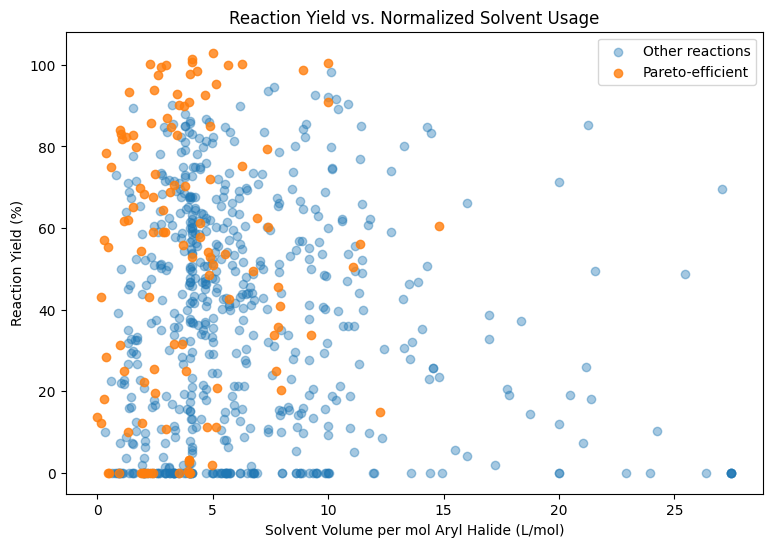

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    efficiency_df.loc[
        ~efficiency_df["pareto_efficient"],
        "solvent_l_per_mol_aryl"
    ],
    efficiency_df.loc[
        ~efficiency_df["pareto_efficient"],
        "yield_percent"
    ],
    alpha=0.4,
    label="Other reactions"
)

plt.scatter(
    efficiency_df.loc[
        efficiency_df["pareto_efficient"],
        "solvent_l_per_mol_aryl"
    ],
    efficiency_df.loc[
        efficiency_df["pareto_efficient"],
        "yield_percent"
    ],
    alpha=0.8,
    label="Pareto-efficient"
)

plt.xlabel("Solvent Volume per mol Aryl Halide (L/mol)")
plt.ylabel("Reaction Yield (%)")
plt.title("Reaction Yield vs. Normalized Solvent Usage")
plt.legend()

plt.show()

## 66. Pareto efficiency across major reaction classes

The previous table showed that reaction classes have different proportions of
Pareto-efficient reactions.

I will now restrict the comparison to reaction classes with at least 10
reactions in the analytical dataset.

This avoids drawing conclusions from reaction classes represented by only one
or two observations.

In [ ]:
major_types = (
    efficiency_df["reaction_type"]
    .value_counts()
)

major_types = major_types[
    major_types >= 10
].index

major_type_df = efficiency_df[
    efficiency_df["reaction_type"].isin(major_types)
].copy()

major_type_summary = (
    major_type_df
    .groupby("reaction_type")
    .agg(
        reactions=("reaction_id", "count"),
        pareto_efficient=("pareto_efficient", "sum"),
        median_yield=("yield_percent", "median"),
        median_solvent=("solvent_l_per_mol_aryl", "median"),
        median_catalyst=("catalyst_mass_per_mol_aryl", "median"),
        median_temperature=("temperature_c", "median")
    )
)

major_type_summary["pareto_percentage"] = (
    major_type_summary["pareto_efficient"]
    / major_type_summary["reactions"]
    * 100
)

major_type_summary.sort_values(
    "pareto_percentage",
    ascending=False
)

,reactions,pareto_efficient,median_yield,median_solvent,median_catalyst,median_temperature,pareto_percentage
reaction_type,,,,,,,
1.3.6 [N-arylation with Ar-X] Bromo N-arylation,15,7,21.219999,2.463054,23.706748,115.0,46.666667
0.0 [Unassigned] Unrecognized,86,18,49.055000,6.172652,55.414852,100.0,20.930233
1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination,242,47,43.445000,4.562386,72.355353,100.0,19.421488
1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination,283,34,32.779999,4.437870,82.438557,100.0,12.014134
1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,76,6,48.469999,5.278846,69.195577,92.5,7.894737


## 67. Comparing process trade-offs by reaction type

The Pareto percentage alone does not tell us why a reaction class performs
well.

I will compare the median yield, normalized solvent usage, normalized catalyst
usage and temperature of the major reaction classes.

This provides a more interpretable view of the trade-offs behind the Pareto
frontier.

In [ ]:
major_type_summary[
    [
        "reactions",
        "pareto_efficient",
        "pareto_percentage",
        "median_yield",
        "median_solvent",
        "median_catalyst",
        "median_temperature"
    ]
].sort_values("median_yield",ascending=False)

,reactions,pareto_efficient,pareto_percentage,median_yield,median_solvent,median_catalyst,median_temperature
reaction_type,,,,,,,
0.0 [Unassigned] Unrecognized,86,18,20.930233,49.055000,6.172652,55.414852,100.0
1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,76,6,7.894737,48.469999,5.278846,69.195577,92.5
1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination,242,47,19.421488,43.445000,4.562386,72.355353,100.0
1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination,283,34,12.014134,32.779999,4.437870,82.438557,100.0
1.3.6 [N-arylation with Ar-X] Bromo N-arylation,15,7,46.666667,21.219999,2.463054,23.706748,115.0


## 68. Screening for high-performing, resource-efficient reactions

Pareto efficiency identifies useful trade-offs, but a Pareto-efficient reaction
can still have a relatively low yield.

To identify practically attractive processes, I will apply a simple screening
step using thresholds derived from the dataset itself.

A reaction will be considered a promising process when it has:

- Yield of at least 70%
- Below-median normalized solvent usage
- Below-median normalized catalyst usage
- Below-median reaction temperature

These criteria are intended as an exploratory data-analysis filter, not as a
formal definition of green chemistry.

In [ ]:
yield_threshold = 70

solvent_threshold = efficiency_df[
    "solvent_l_per_mol_aryl"
].median()

catalyst_threshold = efficiency_df[
    "catalyst_mass_per_mol_aryl"
].median()

temperature_threshold = efficiency_df[
    "temperature_c"
].median()

print("Yield threshold:", yield_threshold, "%")
print("Median normalized solvent:",
      round(solvent_threshold, 3), "L/mol")
print("Median normalized catalyst:",
      round(catalyst_threshold, 3), "g/mol")
print("Median temperature:",
      round(temperature_threshold, 1), "°C")

Yield threshold: 70 %
Median normalized solvent: 4.68 L/mol
Median normalized catalyst: 73.577 g/mol
Median temperature: 100.0 °C


## 69. Identifying promising process conditions

I will apply the screening criteria to the analytical dataset.

The resulting reactions represent cases where relatively high reaction yield
is achieved while using below-median amounts of solvent and catalyst and a
below-median reaction temperature.

In [ ]:
promising = efficiency_df[
    (efficiency_df["yield_percent"] >= yield_threshold) &
    (efficiency_df["solvent_l_per_mol_aryl"] <= solvent_threshold) &
    (efficiency_df["catalyst_mass_per_mol_aryl"] <= catalyst_threshold) &
    (efficiency_df["temperature_c"] <= temperature_threshold)
].copy()

print("Promising reactions:", len(promising))

print(
    "Percentage of analytical dataset:",
    round(len(promising) / len(efficiency_df) * 100, 2),
    "%"
)

promising.sort_values(
    "yield_percent",
    ascending=False
).head(20)

Promising reactions: 25
Percentage of analytical dataset: 3.49 %


,reaction_id,reaction_type,yield_percent,reactant_mass_per_mol_aryl,reagent_mass_per_mol_aryl,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl,temperature_c,dominated,pareto_efficient
183,ord-ba7ec5906e7d4fb89a5c2ef7e7a905ac,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.300003,387.820000,14.659635,49.264144,2.269693,90.0,False,True
219,ord-122adeafa04f44969e42186d0dc6c6bd,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,97.470001,344.050028,463.004531,73.017372,2.631579,100.0,False,True
551,ord-c0d27ca6d70a4e629ed6ea0a3371d1c9,1.3.6 [N-arylation with Ar-X] Bromo N-arylation,93.739998,282.756320,412.142861,23.706748,2.463054,60.0,False,True
431,ord-316cf52c137541f4a2a9960bf7cb84d3,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,92.540001,358.280000,144.240211,58.010294,4.647160,100.0,False,True
580,ord-d96d0e3f2950466bac2ca8525ac77415,0.0 [Unassigned] Unrecognized,90.870003,370.584802,191.444224,57.990800,3.984064,90.0,False,True
617,ord-9faf2ea031204c63b2d52d8ff6231013,1.3.6 [N-arylation with Ar-X] Bromo N-arylation,90.180000,333.623175,16.290900,46.306546,3.533569,100.0,False,True
261,ord-fb9234fb5e36477680c49d193f20e84f,0.0 [Unassigned] Unrecognized,89.910004,364.652000,14.335992,30.443337,3.750000,90.0,False,True
401,ord-2c85deae4d144af0a18fb548e5e9eabd,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,84.870003,320.209191,466.796936,30.574609,2.884615,100.0,True,False
505,ord-1e9ec853eb3e43adb71af85c977827e9,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,84.739998,307.029000,785.019964,14.719001,3.198294,100.0,False,True
578,ord-8dd14463cf6743e7a0d8b8896c9d7de0,0.0 [Unassigned] Unrecognized,83.629997,370.584802,191.444224,45.984700,3.984064,90.0,True,False


## 70. Reaction classes among promising processes

I will examine which reaction classes appear among the promising processes.

This helps move the analysis from individual reactions toward identifying
reaction classes that repeatedly show favorable combinations of yield and
resource usage.

In [ ]:
promising_type_summary = (
    promising
    .groupby("reaction_type")
    .agg(
        promising_reactions=("reaction_id", "count"),
        median_yield=("yield_percent", "median"),
        median_solvent=("solvent_l_per_mol_aryl", "median"),
        median_catalyst=("catalyst_mass_per_mol_aryl", "median"),
        median_temperature=("temperature_c", "median")
    )
    .sort_values(
        "promising_reactions",
        ascending=False
    )
)

promising_type_summary

,promising_reactions,median_yield,median_solvent,median_catalyst,median_temperature
reaction_type,,,,,
1.3.1 [N-arylation with Ar-X] Bromo Buchwald-Hartwig amination,9,83.589996,3.030303,53.645527,100.0
0.0 [Unassigned] Unrecognized,8,79.875000,3.684409,38.214018,90.0
1.3.2 [N-arylation with Ar-X] Chloro Buchwald-Hartwig amination,3,78.449997,2.269693,49.264144,90.0
1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Hartwig amination,3,74.870003,4.140127,69.189401,100.0
1.3.6 [N-arylation with Ar-X] Bromo N-arylation,2,91.959999,2.998312,35.006647,80.0


## 71. Comparing promising and other reactions

The screening step identified 25 reactions that combine high yield with
relatively low solvent usage, catalyst usage and temperature.

I will now compare these reactions against the remaining reactions in the
analytical dataset.

This helps identify which process variables differ most between the two groups.

In [ ]:
analysis_df["promising"] = (
    analysis_df["reaction_id"].isin(
        promising["reaction_id"]
    )
)

comparison = (
    analysis_df
    .groupby("promising")
    [
        [
            "yield_percent",
            "temperature_c",
            "reactant_mass_per_mol_aryl",
            "reagent_mass_per_mol_aryl",
            "catalyst_mass_per_mol_aryl",
            "solvent_l_per_mol_aryl"
        ]
    ]
    .median()
)

comparison.index = [
    "Other reactions",
    "Promising reactions"
]

comparison

,yield_percent,temperature_c,reactant_mass_per_mol_aryl,reagent_mass_per_mol_aryl,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl
Other reactions,37.410000,100.0,441.963,224.426000,74.033831,4.776119
Promising reactions,79.910004,100.0,364.652,144.240211,49.264144,3.333333


## 72. Measuring the difference between groups

To make the comparison easier to interpret, I will calculate the percentage
difference between the promising reactions and the rest of the dataset.

This shows how strongly the screened group differs in yield, temperature and
resource usage from the remaining reactions.

In [ ]:
other = comparison.loc["Other reactions"]
promising_values = comparison.loc["Promising reactions"]

relative_difference = (
    (promising_values - other)
    / other.abs()
    * 100
)

relative_difference.to_frame(
    "difference_percent"
)

,difference_percent
yield_percent,113.605998
temperature_c,0.000000
reactant_mass_per_mol_aryl,-17.492641
reagent_mass_per_mol_aryl,-35.729278
catalyst_mass_per_mol_aryl,-33.457254
solvent_l_per_mol_aryl,-30.208331


## 73. Visual comparison of process characteristics

I will visualize the median values for promising and other reactions.

Because the variables have very different units and scales, each variable will
be normalized relative to the median of the other reactions.

A value of 1 therefore represents the median of the remaining reactions.
Values below 1 indicate lower resource usage, while values above 1 indicate
higher values.

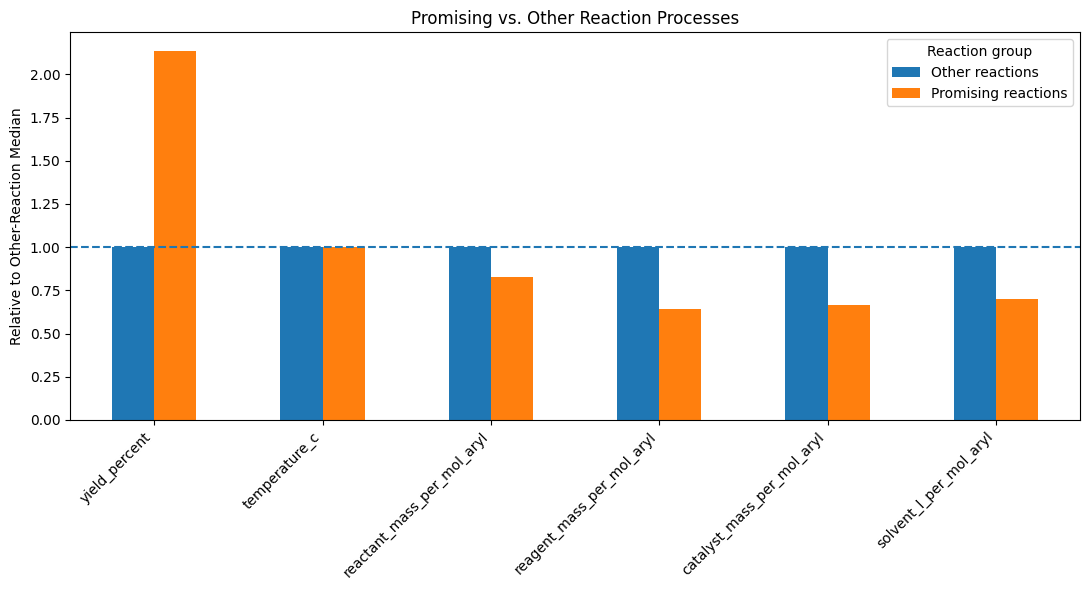

In [ ]:
metrics = [
    "yield_percent",
    "temperature_c",
    "reactant_mass_per_mol_aryl",
    "reagent_mass_per_mol_aryl",
    "catalyst_mass_per_mol_aryl",
    "solvent_l_per_mol_aryl"
]

normalized_comparison = comparison.copy()

for column in metrics:
    normalized_comparison[column] = (
        normalized_comparison[column]
        / comparison.loc["Other reactions", column]
    )

normalized_comparison.T.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(
    1,
    linestyle="--"
)

plt.ylabel("Relative to Other-Reaction Median")
plt.title("Promising vs. Other Reaction Processes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Reaction group")

plt.tight_layout()
plt.show()

## 74. Estimating material efficiency

Yield alone does not capture how efficiently a reaction converts its inputs
into the desired product.

To move closer to process-level environmental analysis, I will estimate the
mass of the desired product from its product SMILES and compare it with the
reported input material.

The resulting metric will provide a reaction-level measure of how much
material is used relative to the desired product obtained.

Only reactions with sufficient reported mass information will be included.

In [ ]:
def get_product_mw(reaction):

    for outcome in reaction.outcomes:

        for product in outcome.products:

            if not product.is_desired_product:
                continue

            for identifier in product.identifiers:

                if identifier.type == identifier.SMILES:

                    mol = Chem.MolFromSmiles(identifier.value)

                    if mol is not None:
                        return Descriptors.MolWt(mol)

    return np.nan

## 75. Calculating desired-product molecular weight

The desired product SMILES is available for each reaction, so I can calculate
its molecular weight using RDKit.

This does not yet give the actual amount of product obtained. The molecular
weight will be combined with reaction scale and reported yield in the next step
to estimate product mass for reactions where the required information is
available.

In [ ]:
product_mw = []

for rxn in dataset.reactions:
    product_mw.append(
        get_product_mw(rxn)
    )

df["product_mw_g_mol"] = product_mw

print(
    "Reactions with calculated product molecular weight:",
    df["product_mw_g_mol"].notna().sum()
)

df["product_mw_g_mol"].describe()

Reactions with calculated product molecular weight: 750


,product_mw_g_mol
count,750.000000
mean,344.731909
std,96.702926
min,112.107000
25%,267.672000
50%,343.349000
75%,434.215500
max,596.713000


## 76. Estimating the desired-product mass

The ORD records report reaction yield and the amount of aryl halide used.

For this analysis, I will use the aryl halide amount as the reaction scale and
estimate the mass of desired product as:

estimated product mass =
aryl halide moles * product molecular weight * yield / 100

This provides a consistent reaction-level estimate that can be compared with
the amount of material used.

The result should be interpreted as an analytical estimate rather than a
directly reported isolated product mass.

In [ ]:
df["estimated_product_mass_g"] = (
    df["aryl_halide_moles"]
    * df["product_mw_g_mol"]
    * df["yield_percent"]
    / 100
)

print(
    "Reactions with estimated product mass:",
    df["estimated_product_mass_g"].notna().sum()
)

df["estimated_product_mass_g"].describe()

Reactions with estimated product mass: 750


,estimated_product_mass_g
count,750.000000
mean,1.244690
std,3.582413
min,0.000000
25%,0.021252
50%,0.108436
75%,0.710321
max,48.792580


## 77. Checking the estimated product mass

Before using the estimated product mass in efficiency calculations, I will
check for zero, negative or unusually large values.

Zero product mass can occur when the reported reaction yield is zero.

In [ ]:
print(
    "Zero estimated product mass:",
    (df["estimated_product_mass_g"] == 0).sum()
)

print(
    "Negative estimated product mass:",
    (df["estimated_product_mass_g"] < 0).sum()
)

print(
    "Maximum estimated product mass:",
    df["estimated_product_mass_g"].max()
)

Zero estimated product mass: 134
Negative estimated product mass: 0
Maximum estimated product mass: 48.792579807575564


## 78. Calculating non-solvent material intensity

To avoid introducing assumptions about solvent density, the first material
efficiency metric will use the reported masses of reactants, reagents and
catalysts.

The metric is:

non-solvent material intensity =
reactant + reagent + catalyst mass
-----------------------------------
estimated product mass

Lower values indicate that less non-solvent material is required per gram of
estimated desired product.

In [ ]:
df["non_solvent_input_mass_g"] = (
    df["reactant_mass_g"]
    + df["reagent_mass_g"]
    + df["catalyst_mass_g"]
)

df["material_intensity"] = (
    df["non_solvent_input_mass_g"]
    / df["estimated_product_mass_g"]
)

df["material_intensity"] = (
    df["material_intensity"]
    .replace([np.inf, -np.inf], np.nan)
)

print(
    "Reactions with calculable material intensity:",
    df["material_intensity"].notna().sum()
)

df["material_intensity"].describe()

Reactions with calculable material intensity: 616


,material_intensity
count,616.000000
mean,12.413295
std,26.316955
min,1.124279
25%,3.452818
50%,5.293128
75%,10.424193
max,324.054040


## 79. Material efficiency of promising reactions

The promising reactions were selected using yield, normalized catalyst,
solvent and temperature criteria.

I will now compare their non-solvent material intensity with the remaining
reactions.

This is an additional efficiency measure and is not part of the original
screening criterion.

In [ ]:
df["promising"] = df["reaction_id"].isin(
    promising["reaction_id"]
)

material_comparison = (
    df.groupby("promising")["material_intensity"]
    .median()
)

material_comparison.index = [
    "Other reactions",
    "Promising reactions"
]

material_comparison

,material_intensity
Other reactions,5.488811
Promising reactions,2.438563


In [ ]:
print(
    "Promising reactions:",
    df["promising"].sum()
)

print(
    "Other reactions:",
    (~df["promising"]).sum()
)

Promising reactions: 25
Other reactions: 725


## 80. Preparing the efficiency dataset

Some reactions have a reported yield of zero, which means no estimated product
mass can be calculated.

These reactions cannot provide a meaningful material-intensity value, so they
will be excluded from the efficiency analysis.

The resulting dataset will be used only for comparing material efficiency,
while the complete dataset will still be retained for the earlier analyses.

In [ ]:
efficiency_df = df[
    (df["estimated_product_mass_g"] > 0) &
    (df["material_intensity"].notna())
].copy()

print(
    "Reactions available for efficiency analysis:",
    len(efficiency_df)
)

print(
    "Promising reactions in efficiency dataset:",
    efficiency_df["promising"].sum()
)

Reactions available for efficiency analysis: 616
Promising reactions in efficiency dataset: 25


## 81. Comparing material-efficiency distributions

The median comparison showed that promising reactions have lower material
intensity.

I will now examine the distribution of material intensity for both groups to
see whether this difference is consistent across the dataset or mainly caused
by a few extreme reactions.

/tmp/ipykernel_791/3492157250.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


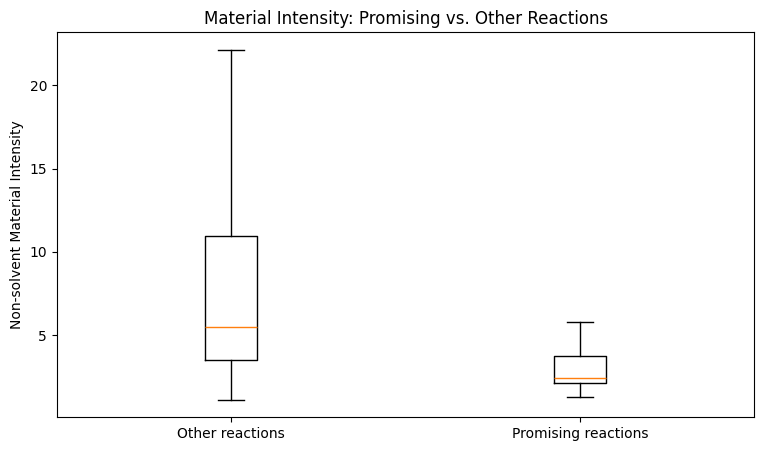

In [ ]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        efficiency_df.loc[
            ~efficiency_df["promising"],
            "material_intensity"
        ],
        efficiency_df.loc[
            efficiency_df["promising"],
            "material_intensity"
        ]
    ],
    labels=["Other reactions", "Promising reactions"],
    showfliers=False
)

plt.ylabel("Non-solvent Material Intensity")
plt.title("Material Intensity: Promising vs. Other Reactions")

plt.show()

## 82. Quantifying material-efficiency improvement

To make the difference easier to communicate, I will calculate the percentage
reduction in median material intensity achieved by the promising reactions
relative to the other reactions.

In [ ]:
other_median = efficiency_df.loc[
    ~efficiency_df["promising"],
    "material_intensity"
].median()

promising_median = efficiency_df.loc[
    efficiency_df["promising"],
    "material_intensity"
].median()

material_reduction = (
    (other_median - promising_median)
    / other_median
    * 100
)

print(
    "Median material intensity - other reactions:",
    round(other_median, 2)
)

print(
    "Median material intensity - promising reactions:",
    round(promising_median, 2)
)

print(
    "Reduction in material intensity:",
    round(material_reduction, 2),
    "%"
)

Median material intensity - other reactions: 5.49
Median material intensity - promising reactions: 2.44
Reduction in material intensity: 55.57 %


## 83. Building a multi-criteria process-efficiency score

No single metric completely describes reaction efficiency.

A reaction can have high yield but consume large amounts of catalyst or solvent.
Conversely, a reaction may use very little material but produce a poor yield.

To capture these trade-offs, I will construct a normalized composite score using:

- reaction yield
- normalized catalyst usage
- normalized solvent usage
- non-solvent material intensity

Each metric will first be converted to a 0–1 scale so that variables with
different units can be compared.

Higher scores will represent better overall process efficiency.

The score is intended as an analytical ranking tool rather than a formal
green-chemistry certification.

In [ ]:
score_df = efficiency_df.copy()

def min_max(series):
    return (
        (series - series.min())
        / (series.max() - series.min())
    )

#Higher yield is better
score_df["yield_score"] = min_max(
    score_df["yield_percent"]
)

#Lower resource usage is better
score_df["catalyst_score"] = 1 - min_max(
    score_df["catalyst_mass_per_mol_aryl"]
)

score_df["solvent_score"] = 1 - min_max(
    score_df["solvent_l_per_mol_aryl"]
)

score_df["material_score"] = 1 - min_max(
    score_df["material_intensity"]
)

#Equal weighting of the four indicators
score_df["efficiency_score"] = (
    score_df["yield_score"]
    + score_df["catalyst_score"]
    + score_df["solvent_score"]
    + score_df["material_score"]
) / 4

score_df[
    [
        "reaction_id",
        "reaction_type",
        "yield_percent",
        "catalyst_mass_per_mol_aryl",
        "solvent_l_per_mol_aryl",
        "material_intensity",
        "efficiency_score"
    ]
].head()

,reaction_id,reaction_type,yield_percent,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl,material_intensity,efficiency_score
0,ord-56b1f4bfeebc4b8ab990b9804e798aa7,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,65.389999,108.055498,NaN,5.005420,NaN
1,ord-1169cbe9fa064a879ac34b2e524a4e69,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,57.470001,78.798300,3.632385,6.663530,0.855889
2,ord-13992005c22d4673aa802b5e140076e8,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,65.430000,78.805604,1.848635,5.862264,0.876369
3,ord-a36b48917c9942d1a34637511773ee1f,1.3.4 [N-arylation with Ar-X] Iodo Buchwald-Ha...,75.070000,78.805604,3.697270,5.109471,0.900013
4,ord-5fc624fd97b7430eafbe8dcc049d170b,0.0 [Unassigned] Unrecognized,46.320000,73.703468,4.710145,3.289004,0.832843


## 84. Ranking the most efficient reaction processes

The composite score allows the reactions to be ranked across multiple
performance and resource-use dimensions simultaneously.

The highest-ranked reactions represent processes that provide a strong
combination of product yield and relatively low material, catalyst and
solvent requirements.

In [ ]:
top_reactions = (
    score_df
    .sort_values(
        "efficiency_score",
        ascending=False
    )
    [
        [
            "reaction_id",
            "reaction_type",
            "yield_percent",
            "temperature_c",
            "catalyst_mass_per_mol_aryl",
            "solvent_l_per_mol_aryl",
            "material_intensity",
            "efficiency_score"
        ]
    ]
    .head(15)
)

top_reactions

,reaction_id,reaction_type,yield_percent,temperature_c,catalyst_mass_per_mol_aryl,solvent_l_per_mol_aryl,material_intensity,efficiency_score
382,ord-b30e73dcf3ae428d887dca581acb0b4f,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,101.529999,120.0,37.940417,4.090909,1.613330,0.981711
380,ord-0624d5800c4b4df5ab74722e43784236,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.610001,120.0,37.793795,4.081633,1.625708,0.979511
183,ord-ba7ec5906e7d4fb89a5c2ef7e7a905ac,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,100.300003,90.0,49.264144,2.269693,1.281859,0.975391
640,ord-218b24f2d22444388b751f136d342319,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,98.650002,85.0,38.938918,8.918919,1.903384,0.972909
600,ord-3016ae12f45142f49e43a15eaa293eb1,1.3.7 [N-arylation with Ar-X] Chloro N-arylation,93.419998,110.0,8.158670,1.388889,2.140788,0.972778
381,ord-f324903a1dbf436dad59daccca5918c2,1.3.2 [N-arylation with Ar-X] Chloro Buchwald-...,97.769997,120.0,37.954477,4.032258,1.673955,0.972500
189,ord-33a377364ac14bd183dfd7eb0108a408,0.0 [Unassigned] Unrecognized,100.379997,110.0,51.824947,10.000000,3.879832,0.970748
551,ord-c0d27ca6d70a4e629ed6ea0a3371d1c9,1.3.6 [N-arylation with Ar-X] Bromo N-arylation,93.739998,60.0,23.706748,2.463054,4.094052,0.966250
128,ord-57d5091f100248ff80a0ef888a43c83e,0.0 [Unassigned] Unrecognized,98.309998,110.0,51.824949,10.112359,4.084444,0.965512
219,ord-122adeafa04f44969e42186d0dc6c6bd,1.3.1 [N-arylation with Ar-X] Bromo Buchwald-H...,97.470001,100.0,73.017372,2.631579,3.774005,0.958019


##Conclusion
This project started with a fairly simple question: what can a reaction database tell us about how synthetic reactions are actually being carried out? After working through the ORD data, it became clear that the answer is more useful when yield is considered alongside the resources required to obtain it.
The dataset contained 750 reactions, covering mainly Buchwald-Hartwig and related N-arylation reactions. Most records had temperature and yield information, while the input structures could be successfully parsed from their SMILES representations. At the same time, the analysis showed some of the limitations of real experimental data: missing measurements, unclassified reactions, and a small number of reported yields above 100%.

Temperature by itself did not explain much of the variation in yield. The Spearman correlation was only -0.099, suggesting that simply increasing or decreasing the reaction temperature is not enough to account for reaction performance. The same pattern appeared when looking at normalized quantities of reactants, reagents, catalyst, and solvent. Their individual correlations with yield were weak, which is not surprising for a chemical system where the outcome depends on the particular substrates and reaction conditions rather than on one variable in isolation.

The more interesting result came from looking at yield and resource usage together. Using normalized material quantities, I identified reactions that were Pareto-efficient, those that offered a useful balance between high yield and lower resource consumption. Out of the analytical dataset, 116 reactions (16.2%) fell on this Pareto frontier. A stricter definition of promising reactions reduced this to 25 reactions, allowing the analysis to focus on experiments that combined good synthetic performance with relatively efficient use of materials.

The material-intensity analysis made this difference particularly clear. The median material intensity dropped from 5.49 for the other reactions to 2.44 for the promising subset, corresponding to a 55.57% reduction. In other words, the reactions selected as promising were not simply the ones with the highest yields; they also tended to achieve those yields with substantially less material input.

There are some important caveats. Material intensity is based on the quantities reported in the database and, where necessary, an estimated product mass. 134 reactions had zero estimated product mass, so they could not be included in the material-efficiency calculation. Reaction classes were also unevenly represented, meaning that the results for classes with only a few examples should not be treated as general conclusions.

Overall, the analysis shows how a reaction database can be used to move beyond simply asking "Which reaction gave the highest yield?" A better question is which experimental conditions provide a good combination of yield, material usage, and practical reaction conditions? The Pareto and material-efficiency analyses provide a way of answering that question directly, while also showing where the underlying experimental data needs to be treated with caution.
The main outcome of the project is therefore not a single "best" reaction condition. It is a data-driven framework for identifying and comparing synthetically effective and resource-efficient reactions from experimental reaction records.